# Macro-Financial Relationship Analysis

**What this notebook does.** For each macro-financial relationship below it
produces (a) a *graph* and (b) a *correlation coefficient* — but it refuses to
report a naive levels correlation as the headline. Every number is computed
under four supervising principles so that the figures are honest rather than
spurious.

### The four supervising principles

1. **Non-stationarity / avoid spurious correlation.** Two trending (I(1))
   series will correlate at ~0.9 even when unrelated. We run an **ADF test** on
   every series, classify it **I(0)** (stationary) or **I(1)** (needs
   differencing), and compute the headline correlation on the *stationary*
   transform (growth rates / first differences). When **both** series are I(1)
   we additionally run a **Johansen cointegration test** to check for a genuine
   long-run relationship, and we report the levels correlation only with an
   explicit *"spurious unless cointegrated"* caveat.

2. **Lead / lag over contemporaneous.** Economic relationships are rarely
   simultaneous. For every pair we compute the **cross-correlation function**
   over lags −12…+12 months (−8…+8 if quarterly), report the contemporaneous
   value, the **peak** correlation and the **lag** at which it occurs (the
   *lead/lag shift*), flag which lags pierce the 95% band (±1.96/√n), and note
   where the lagged correlation is materially stronger than the contemporaneous
   one — the cases a static correlation matrix would miss.

3. **Regime-dependence / structural breaks.** We do **not** assume one stable
   coefficient. We detect **structural breaks** with the `ruptures` package, plot
   a **rolling correlation** so sign-flips are visible, and report the
   correlation **per regime**, flagging explicit sign flips. The Phillips curve
   and the interest-differential/FX relationship are treated as prime suspects.

4. **Common-driver screen.** Oil, inflation and rates move together because the
   same shock hits all three. For the at-risk pairs we compute a **partial
   correlation** controlling a common driver and print **raw vs partial** side
   by side — does the relationship survive the control or collapse?

> Each section opens with a plain-English note on the *expected* economics and
> *which principles bite hardest* for that pair, so the notebook documents its
> own methodology as it runs.

## 0 · Configuration  *(paths, column map, WB_SPEC)*

**Set everything here, then Run All.** This notebook supports two input layouts,
selected by `LAYOUT`:

* **`"master_workbook"`** *(default)* — the multi-sheet *Trading-Economics / FRED /
  Bank-of-Canada* **US & Canada** workbook (`master_economics_data.xlsx`). Series
  live across many differently-shaped sheets, at mixed native frequencies (GDP &
  output gap quarterly; CPI/PPI/unemployment monthly; rates/FX daily). The loader
  in §4 reads each series from its sheet/column, **down-samples everything to a
  common quarterly grid** (the honest choice — quarterly is the binding frequency
  of GDP growth and the output gap), and **derives** two series that aren't stored
  directly: the **US output gap** (real GDP ÷ CBO potential − 1) and the
  **US−Canada interest-rate differential**. The extraction map is `WB_SPEC` below
  — fully editable and self-documenting.

* **`"single_sheet"`** — a plain workbook with one sheet: a date column + one
  column per series. Edit `COLMAP` to map logical names → your column headers.

> **Scope of the default run:** *US-primary, quarterly.* **WTI crude price is not
> in the workbook** (only oil-production volumes), so the energy series and the
> Principle-4 common-driver both fall back to **US Energy Inflation**. The FX
> relationship pairs **USD/CAD** with the **US−Canada policy-rate differential**.
> Any series that cannot be found is reported and its relationship skipped.

In [1]:
# === EDIT THIS CELL ========================================================
from pathlib import Path

LAYOUT      = "master_workbook"    # "master_workbook" | "single_sheet"
EXCEL_PATH  = "~/Downloads/master_economics_data.xlsx"   # path/filename of your workbook
FREQUENCY   = "Q"                  # "M" = monthly, "Q" = quarterly
OUTPUT_DIR  = "."                  # where PNGs / CSVs are written

# --- single_sheet layout only: date column + logical->header map -----------
SHEET_NAME  = 0                    # sheet name (str) or index (int)
DATE_COLUMN = "date"               # header of the date column
COLMAP = {
    "gdp_growth": "real_gdp_growth", "unemployment": "unemployment_rate",
    "cpi": "cpi", "core_cpi": "core_cpi", "ppi": "ppi",
    "output_gap": "output_gap", "policy_rate": "fed_funds_rate",
    "prime_rate": "prime_rate", "spread_10y3m": "spread_10y_3m",
    "spread_10y2y": "spread_10y_2y", "wti": "wti_crude",
    "energy_ppi": "energy_ppi", "exchange_rate": "usd_index",
    "ir_differential": "ir_differential",
}

# --- master_workbook layout: how to extract each series --------------------
# spec = dict(sheet, country, col, kind, agg) OR dict(derive=...).
#   kind:  "two"  -> 2-row-header thematic sheet (country row + indicator row)
#          "single"-> Date-keyed wide sheet (one header row)
#          "two1" -> single-indicator sheet (Date | US | Canada)
#   col:   exact indicator/column label to match (substring, case-insensitive)
#   agg:   "last" (period-end, for index levels) | "mean" (for rates/%/spreads)
WB_SPEC = {
    "gdp_growth":   dict(sheet="GDP Growth Rate", kind="two1", country="United States", agg="mean"),
    "unemployment": dict(sheet="Unemployment Rate", kind="two1", country="United States", agg="mean"),
    "cpi":          dict(sheet="Prices", kind="two", country="United States",
                         col="Consumer Price Index CPI", agg="last"),
    "core_cpi":     dict(sheet="Prices", kind="two", country="United States",
                         col="Core Consumer Prices", agg="last"),
    "ppi":          dict(sheet="Prices", kind="two", country="United States",
                         col="Producer Prices", agg="last"),
    "policy_rate":  dict(sheet="US Financial Conditions", kind="single",
                         col="Eff. Fed Funds", agg="mean"),
    "prime_rate":   dict(sheet="Consumer", kind="two", country="United States",
                         col="Bank Lending Rate", agg="mean"),
    "spread_10y3m": dict(sheet="US Financial Conditions", kind="single",
                         col="10Y-3M Spread", agg="mean"),
    "spread_10y2y": dict(sheet="US Financial Conditions", kind="single",
                         col="10Y-2Y Spread", agg="mean"),
    # WTI price absent in workbook -> intentionally omitted (warn+skip).
    "energy_ppi":   dict(sheet="Prices", kind="two", country="United States",
                         col="Energy Inflation", agg="mean"),  # energy CPI inflation (%)
    "exchange_rate": dict(sheet="Canada (BoC)", kind="single",
                          col="USD/CAD FX", agg="mean"),
    # REV 8 additions (literature-backed, non-credit):
    "vix":          dict(sheet="US Financial Conditions", kind="single",
                         col="VIX", agg="mean"),           # equity-vol / uncertainty
    # ---- REV 10: Canadian counterparts (for US|Canada side-by-side) ----
    "gdp_growth_ca":   dict(sheet="GDP Growth Rate", kind="two1", country="Canada", agg="mean"),
    "unemployment_ca": dict(sheet="Unemployment Rate", kind="two1", country="Canada", agg="mean"),
    "cpi_ca":          dict(sheet="Prices", kind="two", country="Canada",
                            col="Consumer Price Index CPI", agg="last"),
    "energy_ppi_ca":   dict(sheet="Prices", kind="two", country="Canada",
                            col="Energy Inflation", agg="mean"),
    "policy_rate_ca":  dict(sheet="Interest Rate", kind="two1", country="Canada", agg="mean"),
    "output_gap_ca":   dict(sheet="Potential GDP & Output Gap", kind="single",
                            col="Output gap - Current MPR", agg="mean"),  # BoC MPR gap (%)
    # Derived series (computed after extraction):
    "output_gap":   dict(derive="output_gap"),        # 100*(realGDP/potential-1)
    "ir_differential": dict(derive="ir_differential"), # US FedFunds - CA overnight
    "spread_10y2y_ca": dict(derive="spread_10y2y_ca"), # GoC 10Y - GoC 2Y (CA slope proxy)
}
# Building blocks needed only to derive the computed series above:
WB_DERIVE_INPUTS = {
    "_us_real_gdp":  dict(sheet="GDP", kind="two", country="United States",
                          col="GDP Constant Prices", agg="last"),
    "_us_potential": dict(sheet="Potential GDP & Output Gap", kind="single",
                          col="Potential GDP - Real", agg="last"),
    "_ca_overnight": dict(sheet="Canada (BoC)", kind="single",
                          col="Target Overnight Rate", agg="mean"),
    "_goc_10y":      dict(sheet="Canada (BoC)", kind="single",
                          col="GoC 10Y Yield", agg="mean"),
    "_goc_2y":       dict(sheet="Canada (BoC)", kind="single",
                          col="GoC 2Y Yield", agg="mean"),
    # _us_fedfunds reuses the policy_rate extraction.
}

# Source/provenance labels for the Data Asset catalogue (both layouts).
SOURCES = {
    "gdp_growth": "FRED — Real GDP growth, SAAR (A191RL1Q225SBEA, US, 1947+)",
    "unemployment": "FRED — Unemployment Rate (UNRATE, US, 1948+)",
    "cpi": "Trading Economics/FRED (US)", "core_cpi": "Trading Economics/FRED (US)",
    "ppi": "Trading Economics/FRED (US)",
    "output_gap": "Derived: BEA real GDP / CBO potential (US)",
    "policy_rate": "FRED — Eff. Fed Funds (US)", "prime_rate": "Trading Economics — Bank Lending Rate (US)",
    "spread_10y3m": "FRED — Treasury (US)",
    "spread_10y2y": "FRED — 10Y−2Y Treasury slope (T10Y2Y, US, 1976+)",
    "wti": "N/A — not in workbook", "energy_ppi": "Trading Economics — Energy Inflation (US)",
    "exchange_rate": "Bank of Canada — USD/CAD",
    "vix": "CBOE/FRED — VIX (US)",
    # REV 10 Canadian counterparts:
    "gdp_growth_ca": "Trading Economics (Canada)", "unemployment_ca": "Trading Economics (Canada)",
    "cpi_ca": "Trading Economics/StatCan (Canada)", "energy_ppi_ca": "Trading Economics — Energy Inflation (Canada)",
    "policy_rate_ca": "Bank of Canada — policy rate (Canada)",
    "output_gap_ca": "Bank of Canada — MPR output gap % (Canada)",
    "spread_10y2y_ca": "Derived: GoC 10Y − GoC 2Y yield (Canada)",
    "ir_differential": "Derived: US Eff. Fed Funds − BoC overnight",
}

# --- Derived analysis parameters (no need to edit) -------------------------
MAX_LAG     = 12                                # CCF window (±12 periods, M or Q)
ROLL_WINDOW = 36 if FREQUENCY == "M" else 12    # rolling-correlation window
PERIODS_YR  = 12 if FREQUENCY == "M" else 4     # periods per year (for YoY)
ALPHA       = 0.05                              # significance level
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
print(f"Layout={LAYOUT}  Frequency={FREQUENCY}  "
      f"MAX_LAG={MAX_LAG}  ROLL_WINDOW={ROLL_WINDOW}")

Layout=master_workbook  Frequency=Q  MAX_LAG=12  ROLL_WINDOW=12


## 0.1 · Imports & runtime setup

In [2]:
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import ruptures as rpt

# Self-contained time-varying Okun (Beaton/SW/LP) helper module sits next to
# this notebook. Import is optional: if unavailable, §2.1a degrades gracefully.
sys.path.insert(0, str(Path(__file__).parent) if "__file__" in dir() else ".")
try:
    import okun_tvp as _okun_tvp
except Exception as _e:                       # noqa: BLE001
    _okun_tvp = None
    print(f"NOTE: okun_tvp module unavailable ({_e}); TVP Okun section will skip.")

warnings.filterwarnings("ignore")           # silence noisy ADF/Johansen warnings
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110
SUMMARY = []                                  # master-summary rows accumulate here
FIGURES = []                                  # saved figure paths accumulate here
ROLLING = []                                  # long rolling-corr rows (date, rel, r)
DASH    = []                                  # long dashboard metric rows
CCF     = []                                  # long cross-correlation rows (rel, lag, r, ...)
SERIES  = []                                  # long transformed-pair rows (rel, date, x, y)
BREAKS  = []                                  # long structural-break rows (rel, break_date)
OKUN_TVP = []                                 # long TVP-slope rows (date, total, lo, hi, country)
OKUN_TVP_REGIMES = []                         # per-regime smoothed-slope averages by country

## 0.2 · Methodology helpers

These functions implement the four principles once, so each relationship
section stays short and the *method* is auditable in one place.

* `adf_report` — ADF stationarity test → `I(0)` / `I(1)`.
* `apply_transform` — choose & apply the honest transform (level vs difference vs % vs YoY).
* `cross_corr` — cross-correlation function with the 95% significance band.
* `johansen_test` — long-run cointegration check for two I(1) series.
* `partial_corr` — raw vs driver-controlled correlation.
* `detect_breaks` — structural breaks on the OLS residual of the relationship.
* `regime_corrs` — per-regime correlation + sign-flip flag.
* `rolling_corr` — moving-window correlation (regime visualisation).
* `analyze_relationship` — orchestrates all of the above, prints the report and
  draws/saves the two-panel figure.

In [3]:
# --------------------------------------------------------------------------
# PRINCIPLE 1 helpers: stationarity & transforms
# --------------------------------------------------------------------------
def adf_report(series, name=""):
    """ADF test -> classify I(0) (stationary) or I(1) (unit root, diff needed)."""
    s = pd.Series(series).dropna()
    out = {"name": name, "n": int(len(s)), "order": "n/a",
           "p_level": np.nan, "p_diff": np.nan}
    if len(s) < 12:
        return out
    p_level = adfuller(s, autolag="AIC")[1]
    out["p_level"] = p_level
    if p_level < 0.05:
        out["order"] = "I(0)"                       # already stationary
    else:
        d = s.diff().dropna()
        p_diff = adfuller(d, autolag="AIC")[1] if len(d) > 12 else np.nan
        out["p_diff"] = p_diff
        out["order"] = "I(1)" if (pd.notna(p_diff) and p_diff < 0.05) else "I(1+)"
    return out


def apply_transform(s, kind):
    """Return (transformed_series, human_label) for the requested transform.

    kind:
      "auto"  -> level if ADF says I(0), else first difference (the honest rule)
      "level" -> use as-is (rates, spreads, output gap: already stationary)
      "diff"  -> first difference
      "pct"   -> period-on-period % change
      "yoy"   -> year-on-year % change (the standard inflation measure)
      "yoy_diff" -> change in YoY inflation (inflation acceleration; the
                    accelerationist Phillips-curve dependent variable)
    """
    s = pd.Series(s).astype(float)
    if kind == "level":
        return s, "levels"
    if kind == "diff":
        return s.diff(), "Δ first-difference"
    if kind == "pct":
        return s.pct_change() * 100.0, "% change"
    if kind == "yoy":
        return s.pct_change(PERIODS_YR) * 100.0, f"YoY % ({PERIODS_YR}p)"
    if kind == "yoy_diff":
        # Change in YoY inflation (inflation ACCELERATION) — the dependent
        # variable of the accelerationist / expectations-augmented Phillips curve
        # (Gordon's triangle model; Stock & Watson 1999). Differencing the
        # inflation level strips the regime/trend component that otherwise swamps
        # the demand-pull signal, so the output gap enters with its correct sign.
        return (s.pct_change(PERIODS_YR) * 100.0).diff(), \
            f"Δ YoY % (inflation accel., {PERIODS_YR}p)"
    # auto
    rep = adf_report(s)
    # Treat I(1) AND I(1+) (still non-stationary after one diff) as needing a
    # difference — Principle 1 forbids correlating a non-stationary level.
    if rep["order"].startswith("I(1"):
        return s.diff(), "Δ first-diff (auto: non-stationary→differenced)"
    return s, "levels (auto: I(0))"


# --------------------------------------------------------------------------
# PRINCIPLE 2 helper: cross-correlation function
# --------------------------------------------------------------------------
def cross_corr(x, y, max_lag):
    """Cross-correlation r(k) = corr(x_t, y_{t+k}).

    LAG-SIGN CONVENTION (read this):
        POSITIVE lag = X LEADS Y  (X's PAST correlates with Y's PRESENT).
        This is implemented as  corr(X[t-k], Y[t])  ==  corr(X_t, Y_{t+k}).
        Concretely, for k > 0 we shift Y back by k (df["y"].shift(-k)) so that
        X_t lines up with Y_{t+k}; an X value at time t is being matched against
        a Y value k periods LATER -> X leads.
        k < 0 -> Y leads X.   k = 0 -> contemporaneous.

    Returns (DataFrame[lag, r, n, sig], band, n_overlap).
    """
    df = pd.concat([pd.Series(x), pd.Series(y)], axis=1).dropna()
    df.columns = ["x", "y"]
    n = len(df)
    band = 1.96 / np.sqrt(n) if n > 0 else np.nan
    rows = []
    for k in range(-max_lag, max_lag + 1):
        pair = pd.concat([df["x"], df["y"].shift(-k)], axis=1).dropna()
        r = pair.iloc[:, 0].corr(pair.iloc[:, 1]) if len(pair) > 3 else np.nan
        rows.append((k, r, len(pair)))
    cc = pd.DataFrame(rows, columns=["lag", "r", "n"])
    cc["sig"] = cc["r"].abs() > band
    return cc, band, n


def describe_ccf(cc, xname, yname):
    """Pull contemporaneous, peak and leading-variable facts out of a CCF table."""
    contemp = cc.loc[cc["lag"] == 0, "r"].iloc[0]
    valid = cc.dropna(subset=["r"])
    peak_row = valid.loc[valid["r"].abs().idxmax()]
    peak_lag = int(peak_row["lag"])
    peak_r = float(peak_row["r"])
    if peak_lag > 0:
        leader = f"{xname} leads {yname} by {peak_lag}p"
        leadvar = xname
    elif peak_lag < 0:
        leader = f"{yname} leads {xname} by {abs(peak_lag)}p"
        leadvar = yname
    else:
        leader = "contemporaneous"
        leadvar = "—"
    stronger = abs(peak_r) > abs(contemp) + 0.05
    return dict(contemp=contemp, peak_lag=peak_lag, peak_r=peak_r,
               leader=leader, leadvar=leadvar, lag_stronger=stronger)


def pick_theory_peak(cc, xname, yname, expected_sign=None, expected_leader=None):
    """Select the THEORY-consistent peak from a CCF table.

    Unlike the auto-peak (largest |r| anywhere — which can latch onto a noisy,
    wrong-signed, long-lag value), the theory-peak is the largest-|r| lag whose
    correlation matches BOTH the expected sign and the expected leading direction:
        expected_sign    : "+" or "-"  (None -> no sign constraint)
        expected_leader  : "x" -> X leads/contemporaneous (lag >= 0)
                           "y" -> Y leads/contemporaneous (lag <= 0)
                           None -> no direction constraint
    If neither constraint is given, the theory-peak == the auto-peak.
    Returns dict(r, lag, leadvar) or dict(r=nan, lag=None, leadvar="none") when no
    lag is theory-consistent.
    """
    valid = cc.dropna(subset=["r"]).copy()
    if expected_sign == "+":
        valid = valid[valid["r"] > 0]
    elif expected_sign == "-":
        valid = valid[valid["r"] < 0]
    if expected_leader == "x":
        valid = valid[valid["lag"] >= 0]
    elif expected_leader == "y":
        valid = valid[valid["lag"] <= 0]
    if valid.empty:
        return dict(r=np.nan, lag=None, leadvar="none")
    row = valid.loc[valid["r"].abs().idxmax()]
    lag = int(row["lag"])
    if lag > 0:
        lv = xname
    elif lag < 0:
        lv = yname
    else:
        lv = "contemporaneous"
    return dict(r=float(row["r"]), lag=lag, leadvar=lv)


# --------------------------------------------------------------------------
# PRINCIPLE 1 helper: Johansen cointegration (only meaningful for two I(1)s)
# --------------------------------------------------------------------------
def johansen_test(x, y):
    df = pd.concat([pd.Series(x), pd.Series(y)], axis=1).dropna()
    if len(df) < 24:
        return {"ok": False, "msg": "too few obs"}
    try:
        res = coint_johansen(df.values, det_order=0, k_ar_diff=1)
        trace0 = float(res.lr1[0])          # H0: rank=0 (no cointegration)
        crit95 = float(res.cvt[0, 1])       # 95% critical value
        return {"ok": True, "trace": trace0, "crit95": crit95,
                "cointegrated": trace0 > crit95}
    except Exception as e:                   # noqa: BLE001
        return {"ok": False, "msg": str(e)}


# --------------------------------------------------------------------------
# PRINCIPLE 4 helper: partial correlation controlling a common driver
# --------------------------------------------------------------------------
def partial_corr(x, y, z):
    """corr(x, y | z): correlate the residuals of x~z and y~z."""
    df = pd.concat([pd.Series(x), pd.Series(y), pd.Series(z)], axis=1).dropna()
    df.columns = ["x", "y", "z"]
    if len(df) < 12:
        return np.nan, np.nan, 0
    raw = df["x"].corr(df["y"])
    Z = sm.add_constant(df["z"])
    rx = df["x"] - sm.OLS(df["x"], Z).fit().predict(Z)
    ry = df["y"] - sm.OLS(df["y"], Z).fit().predict(Z)
    return raw, rx.corr(ry), len(df)


def classify_survival(raw, partial):
    """Does the relationship survive the common-driver control?"""
    if pd.isna(raw) or pd.isna(partial):
        return "n/a"
    if np.sign(raw) != np.sign(partial):
        return "No (flips/collapses)"
    if abs(partial) >= 0.5 * abs(raw):
        return "Yes"
    return "Weakened"


# --------------------------------------------------------------------------
# PRINCIPLE 3 helpers: structural breaks & rolling correlation
# --------------------------------------------------------------------------
def detect_breaks(x, y):
    """ruptures (Pelt, rbf) on the residual of a static OLS y~x.

    Breaks in that residual = breaks in the *relationship* itself.
    """
    df = pd.concat([pd.Series(x), pd.Series(y)], axis=1).dropna()
    df.columns = ["x", "y"]
    if len(df) < 30:
        return []
    X = sm.add_constant(df["x"])
    resid = (df["y"] - sm.OLS(df["y"], X).fit().predict(X)).values
    sig = (resid - resid.mean()) / (resid.std() + 1e-12)
    sig = sig.reshape(-1, 1)
    try:
        algo = rpt.Pelt(model="rbf").fit(sig)
        bkps = algo.predict(pen=2.0 * np.log(len(sig)))
        if len(bkps) > 7:                              # too many -> coarser fit
            algo2 = rpt.Binseg(model="rbf").fit(sig)
            bkps = algo2.predict(n_bkps=3)
    except Exception:                                  # noqa: BLE001
        return []
    return [df.index[b - 1] for b in bkps if 0 < b < len(df)]


def regime_corrs(x, y, breaks):
    """Correlation within each break-delimited regime + sign-flip flag."""
    df = pd.concat([pd.Series(x), pd.Series(y)], axis=1).dropna()
    df.columns = ["x", "y"]
    if df.empty:
        return [], False
    edges = sorted(set([df.index[0], df.index[-1]] +
                       [b for b in breaks if df.index[0] < b < df.index[-1]]))
    segs = []
    for a, b in zip(edges[:-1], edges[1:]):
        seg = df.loc[a:b]
        if len(seg) > 5:
            segs.append((a, b, seg["x"].corr(seg["y"]), len(seg)))
    signs = {np.sign(r) for *_, r, _ in segs if pd.notna(r) and r != 0}
    return segs, (len(signs) > 1)


def rolling_corr(x, y, window):
    df = pd.concat([pd.Series(x), pd.Series(y)], axis=1).dropna()
    df.columns = ["x", "y"]
    return df["x"].rolling(window).corr(df["y"])

In [4]:
def _safe(name):
    return "".join(c if (c.isalnum() or c in "-_") else "_" for c in name).strip("_")


def analyze_relationship(rid, title, xkey, ykey, *,
                         x_transform="auto", y_transform="auto",
                         partial_driver_key=None, driver_transform=None,
                         graph_only=False, expect="", expected_lead=None,
                         expected_sign=None, expected_leader=None, fig_n=None,
                         country="US"):
    """Full single-relationship analysis: prints the report, draws + saves the
    two-panel figure, and returns one master-summary row (or None if skipped).

    expected_sign / expected_leader feed the theory-peak selection (Fix 2);
    fig_n controls the figure filename fig_<cc>_<fig_n>_<x>_vs_<y>.png where the
    country code cc is us / ca / xb (cross-border).
    Side effects: appends the rolling-correlation series to ROLLING and every
    numeric metric (long format) to DASH for the dashboard exports — each record
    is tagged with `country` so the dashboard can show US|Canada side-by-side."""
    _cc = {"US": "us", "Canada": "ca", "Cross-border": "xb"}.get(country, "us")
    xname, yname = xkey, ykey
    x_raw, y_raw = get_series(xkey), get_series(ykey)
    if x_raw is None or y_raw is None:
        missing = ", ".join(k for k, v in [(xkey, x_raw), (ykey, y_raw)] if v is None)
        print(f"[SKIP] {title} [{country}]\n        missing series: {missing}\n")
        return None

    print("=" * 78)
    print(f"{title}   ·   [{country}]")
    print("=" * 78)
    print(f"Expected economics: {expect}\n")

    # --- PRINCIPLE 1: stationarity + transform -----------------------------
    adf_x, adf_y = adf_report(x_raw, xname), adf_report(y_raw, yname)
    xtr, xlab = apply_transform(x_raw, x_transform)
    ytr, ylab = apply_transform(y_raw, y_transform)
    print("[P1] Stationarity & transform")
    print(f"     {xname:<16} ADF order={adf_x['order']:<5} "
          f"(p_lvl={adf_x['p_level']:.3f}) -> transform: {xlab}")
    print(f"     {yname:<16} ADF order={adf_y['order']:<5} "
          f"(p_lvl={adf_y['p_level']:.3f}) -> transform: {ylab}")

    # --- PRINCIPLE 1b: cointegration eligibility -----------------------------
    # Cointegration (Johansen on the RAW LEVELS) is only valid when BOTH series
    # are I(1)/I(1+) in levels. A series is ELIGIBLE iff BOTH:
    #   (a) its raw-level ADF order starts with "I(1"  (I(1) or I(1+)), AND
    #   (b) it is NOT entered via a transform that makes it stationary by
    #       construction — i.e. an already-stationary level (rate, spread, output
    #       gap) OR a stationarising %-transform (YoY / % change). Per FIX 1 these
    #       cannot enter a cointegrating relation even if a finite-sample ADF on
    #       the raw level is borderline (e.g. CPI-YoY vs policy rate -> n/a).
    # A plain first-difference (Δ) of a genuinely I(1) level does NOT disqualify:
    # Johansen still runs on the raw I(1) levels (e.g. the IR-diff/FX pair is
    # correlated on Δ but is genuinely I(1) in levels -> keeps a Yes/No verdict).
    # If EITHER series is ineligible, Cointegrated = "n/a" and Johansen is skipped.
    def _coint_eligible(adf_rep, transform_label):
        lab = str(transform_label).lower()
        stationarised = (lab.startswith("level") or lab.startswith("yoy")
                         or "yoy" in lab or "%" in lab)
        return adf_rep["order"].startswith("I(1") and not stationarised

    elig_x, elig_y = _coint_eligible(adf_x, xlab), _coint_eligible(adf_y, ylab)
    both_coint = elig_x and elig_y
    coint_flag = "n/a"
    if both_coint:
        lev = pd.concat([x_raw, y_raw], axis=1).dropna()
        lev_corr = lev.iloc[:, 0].corr(lev.iloc[:, 1]) if len(lev) > 3 else np.nan
        jo = johansen_test(x_raw, y_raw)
        if jo.get("ok"):
            coint = jo["cointegrated"]
            coint_flag = "Yes" if coint else "No"
            print(f"     Cointegration: both series I(1)-in-levels & eligible -> "
                  f"Johansen runs on raw levels.")
            print(f"     LEVELS corr={lev_corr:+.3f} (*** SPURIOUS unless cointegrated ***)")
            print(f"     Johansen trace={jo['trace']:.2f} vs crit95="
                  f"{jo['crit95']:.2f} -> cointegrated: {coint_flag}")
        else:
            print(f"     Cointegration: both eligible but Johansen n/a "
                  f"({jo.get('msg')}); LEVELS corr={lev_corr:+.3f} (spurious unless cointegrated)")
    else:
        _bad = [nm for nm, ok in [(xname, elig_x), (yname, elig_y)] if not ok]
        print(f"     Cointegration: n/a — {', '.join(_bad)} "
              f"{'is' if len(_bad) == 1 else 'are'} stationary / used in levels "
              f"(a stationary series cannot be cointegrated).")

    # --- PRINCIPLE 2: cross-correlation ------------------------------------
    cc, band, n = cross_corr(xtr, ytr, MAX_LAG)
    facts = describe_ccf(cc, xname, yname)
    headline = facts["contemp"]                 # honest contemporaneous-on-transform
    # Fix 2: report BOTH the auto-peak (largest |r| anywhere) and the theory-peak
    # (largest |r| that matches the expected sign + leading direction).
    auto_r, auto_lag, auto_leadvar = facts["peak_r"], facts["peak_lag"], facts["leadvar"]
    thp = pick_theory_peak(cc, xname, yname, expected_sign, expected_leader)
    print("\n[P2] Lead / lag (cross-correlation)")
    print(f"     Headline corr (contemporaneous, on transform) = "
          f"{headline:+.3f}  (n={n}, 95% band ±{band:.3f})")
    print(f"     Auto-peak   = {auto_r:+.3f} at lag {auto_lag:+d}  ->  {facts['leader']}")
    if np.isnan(thp["r"]):
        print(f"     Theory-peak = none (no lag matches expected "
              f"sign={expected_sign or 'any'} / leader={expected_leader or 'any'})")
    else:
        print(f"     Theory-peak = {thp['r']:+.3f} at lag {thp['lag']:+d}  ->  "
              f"{thp['leadvar']}  (expected sign={expected_sign or 'any'}, "
              f"leader={expected_leader or 'any'})")
    # Divergence flag: different sign OR |lag| gap > 4 quarters.
    diverge = "—"
    if not np.isnan(thp["r"]):
        _signdiff = (np.sign(auto_r) != np.sign(thp["r"]))
        _laggap = abs(auto_lag - thp["lag"])
        if _signdiff or _laggap > 4:
            diverge = (f"auto {auto_r:+.2f}@{auto_lag:+d} vs theory "
                       f"{thp['r']:+.2f}@{thp['lag']:+d}")
            print(f"     DIVERGENCE: auto-peak and theory-peak differ materially "
                  f"({'opposite sign' if _signdiff else f'|lag| gap {_laggap}'}) — "
                  f"the auto-peak may be noisy/spurious; theory-peak shown for honesty.")
    if facts["lag_stronger"]:
        print(f"     NOTE: lagged correlation is materially stronger than the "
              f"contemporaneous one — a static matrix would miss this.")
    sig_lags = cc.loc[cc["sig"], "lag"].tolist()
    print(f"     Lags exceeding 95% band: "
          f"{sig_lags if sig_lags else 'none'}")
    # Sanity-check observed lead/lag against economic theory (do NOT force it).
    _dirhint = expected_lead or expected_leader
    if _dirhint in ("x", "y"):
        exp_var = xname if _dirhint == "x" else yname
        obs_var = facts["leadvar"]
        if obs_var == exp_var:
            print(f"     DIRECTION: matches theory — {exp_var} leads (expected).")
        elif facts["peak_lag"] == 0:
            print(f"     DIRECTION: peak is contemporaneous; theory expects "
                  f"{exp_var} to lead — reported as-is, not forced.")
        else:
            print(f"     DIRECTION WARNING: theory expects {exp_var} to lead, but "
                  f"observed peak has {obs_var} leading — runs opposite to theory; "
                  f"reported as-is, not forced.")

    # --- PRINCIPLE 3: breaks + regimes -------------------------------------
    breaks = detect_breaks(xtr, ytr)
    segs, sign_flip = regime_corrs(xtr, ytr, breaks)
    roll = rolling_corr(xtr, ytr, ROLL_WINDOW)
    print("\n[P3] Regime dependence")
    if breaks:
        print(f"     Break dates: {[b.strftime('%Y-%m') for b in breaks]}")
    else:
        print("     Break dates: none detected")
    for a, b, r, m in segs:
        print(f"     regime {a:%Y-%m}..{b:%Y-%m}: corr={r:+.3f} (n={m})")
    print(f"     SIGN FLIP across regimes: "
          f"{'YES — unstable relationship' if sign_flip else 'no'}")

    # --- PRINCIPLE 4: common-driver screen ---------------------------------
    survival = "n/a"
    raw_pc = part_pc = np.nan
    if partial_driver_key is not None:
        z_raw = get_series(partial_driver_key)
        if z_raw is not None:
            dt = driver_transform or ("auto" if x_transform == "auto" else x_transform)
            ztr, zlab = apply_transform(z_raw, dt)
            raw_pc, part_pc, npc = partial_corr(xtr, ytr, ztr)
            survival = classify_survival(raw_pc, part_pc)
            print("\n[P4] Common-driver screen "
                  f"(controlling {partial_driver_key})")
            print(f"     raw corr     = {raw_pc:+.3f}")
            print(f"     partial corr = {part_pc:+.3f}  (n={npc})")
            print(f"     survives control? {survival}")
        else:
            print(f"\n[P4] driver '{partial_driver_key}' missing — control skipped")

    # --- FIGURE ------------------------------------------------------------
    _pref = f"fig_{_cc}_{fig_n}" if fig_n is not None else f"{_cc}_{rid}"
    fname = f"{_pref}_{_safe(xkey)}_vs_{_safe(ykey)}.png"
    fpath = str(Path(OUTPUT_DIR) / fname)
    if graph_only:
        _figure_graph_only(x_raw, y_raw, xname, yname, cc, band, facts,
                           title, fpath)
    else:
        _figure_two_panel(xtr, ytr, xlab, ylab, xname, yname, facts,
                          roll, headline, breaks, title, fpath)
    print(f"\n[FIG] saved -> {fpath}\n")
    FIGURES.append(fname)

    # --- Collect rolling correlation (long) for rolling_correlations.csv ----
    _roll = roll.dropna()
    for _dt, _rv in _roll.items():
        ROLLING.append({"date": pd.Timestamp(_dt).date(), "country": country,
                        "relationship": title, "rolling_corr": round(float(_rv), 4)})

    # --- Collect the cross-correlation table (long) for ccf_data.csv --------
    for _, _cr in cc.iterrows():
        CCF.append({"relationship": title, "country": country,
                    "lag": int(_cr["lag"]),
                    "r": (round(float(_cr["r"]), 4) if pd.notna(_cr["r"]) else np.nan),
                    "n": int(_cr["n"]),
                    "sig": bool(_cr["sig"]),
                    "band": round(float(band), 4)})

    # --- Collect the aligned transformed pair (long) for series_data.csv ----
    _pair = pd.concat([pd.Series(xtr), pd.Series(ytr)], axis=1).dropna()
    _pair.columns = ["x", "y"]
    for _dt, _rw in _pair.iterrows():
        SERIES.append({"relationship": title, "country": country,
                       "date": pd.Timestamp(_dt).date(),
                       "x": round(float(_rw["x"]), 6),
                       "y": round(float(_rw["y"]), 6),
                       "x_label": f"{xname} [{xlab}]",
                       "y_label": f"{yname} [{ylab}]"})

    # --- Collect detected structural-break dates (long) for breaks_data.csv -
    for _bk in breaks:
        BREAKS.append({"relationship": title, "country": country,
                       "break_date": pd.Timestamp(_bk).date()})

    theory_r = thp["r"]
    theory_lag = thp["lag"]
    row = {
        "Relationship": title,
        "Country": country,
        "Transform": f"{xname}:{xlab.split(' ')[0]} | {yname}:{ylab.split(' ')[0]}",
        "Headline correlation": round(headline, 3),
        "Contemporaneous r": round(facts["contemp"], 3),
        "Auto peak r": round(auto_r, 3),
        "Auto peak lag": auto_lag,
        "Theory peak r": (round(theory_r, 3) if not np.isnan(theory_r) else "none"),
        "Theory peak lag": (theory_lag if theory_lag is not None else "none"),
        "Leading variable": facts["leadvar"],
        "Cointegrated?": coint_flag,
        "Sign-flips across regimes?": "Yes" if sign_flip else "No",
        "Survives common-driver control?": survival,
        "Auto/Theory divergence": diverge,
    }

    # --- Collect every number (long) for dashboard_data.csv -----------------
    _metrics = {
        "n_obs": n,
        "contemporaneous_r": round(facts["contemp"], 4),
        "auto_peak_r": round(auto_r, 4),
        "auto_peak_lag": auto_lag,
        "theory_peak_r": (round(theory_r, 4) if not np.isnan(theory_r) else np.nan),
        "theory_peak_lag": (theory_lag if theory_lag is not None else np.nan),
        "sig_band_95": round(band, 4),
        "raw_partial_corr": (round(raw_pc, 4) if pd.notna(raw_pc) else np.nan),
        "partial_corr": (round(part_pc, 4) if pd.notna(part_pc) else np.nan),
        "sign_flip": 1 if sign_flip else 0,
        "n_breaks": len(breaks),
    }
    for _mn, _mv in _metrics.items():
        DASH.append({"relationship": title, "country": country,
                     "metric_name": _mn, "metric_value": _mv})

    return row


def _figure_two_panel(xtr, ytr, xlab, ylab, xname, yname, facts,
                      roll, headline, breaks, title, fpath):
    """Panel 1: scatter at peak lag + OLS fit. Panel 2: rolling correlation."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.2))
    lag = facts["peak_lag"]

    # Panel 1 — scatter at the PEAK lag
    pair = pd.concat([xtr, ytr.shift(-lag)], axis=1).dropna()
    pair.columns = ["x", "y"]
    if len(pair) > 2:
        ax1.scatter(pair["x"], pair["y"], s=16, alpha=0.55, edgecolor="none")
        b = np.polyfit(pair["x"], pair["y"], 1)
        xs = np.linspace(pair["x"].min(), pair["x"].max(), 100)
        ax1.plot(xs, np.polyval(b, xs), color="crimson", lw=2)
        ax1.annotate(f"slope = {b[0]:+.3f}\nr = {facts['peak_r']:+.3f}\n"
                     f"lag = {lag:+d}p",
                     xy=(0.04, 0.96), xycoords="axes fraction",
                     va="top", ha="left",
                     bbox=dict(boxstyle="round", fc="white", ec="0.7", alpha=0.9))
    ax1.set_xlabel(f"{xname}  [{xlab}]  (t)")
    ax1.set_ylabel(f"{yname}  [{ylab}]  (t+{lag})")
    ax1.set_title(f"Panel 1 · Scatter at peak lag ({lag:+d}p) + OLS fit")
    ax1.grid(alpha=0.25)

    # Panel 2 — rolling correlation with full-sample line + break markers
    ax2.plot(roll.index, roll.values, color="steelblue", lw=1.6,
             label=f"rolling corr ({ROLL_WINDOW}p)")
    ax2.axhline(headline, color="black", ls="-", lw=1.0,
                label=f"full-sample r = {headline:+.3f}")
    ax2.axhline(0, color="0.6", lw=0.8)
    for i, bk in enumerate(breaks):
        ax2.axvline(bk, color="crimson", ls="--", lw=1.1,
                    label="break" if i == 0 else None)
    ax2.set_ylim(-1.05, 1.05)
    ax2.set_xlabel("date")
    ax2.set_ylabel("rolling correlation")
    ax2.set_title("Panel 2 · Rolling correlation (regime view)")
    ax2.legend(loc="lower left", fontsize=8)
    ax2.grid(alpha=0.25)

    fig.suptitle(title, fontsize=12, fontweight="bold")
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    fig.savefig(fpath, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def _figure_graph_only(x_raw, y_raw, xname, yname, cc, band, facts,
                       title, fpath):
    """Relationship 7: dual-axis time series + cross-correlation panel."""
    fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(14, 5.2))

    # Panel 1 — dual-axis time series
    df = pd.concat([x_raw, y_raw], axis=1).dropna()
    df.columns = ["x", "y"]
    ax1.plot(df.index, df["x"], color="navy", lw=1.6, label=xname)
    ax1.set_ylabel(xname, color="navy")
    ax1.tick_params(axis="y", labelcolor="navy")
    ax2 = ax1.twinx()
    ax2.plot(df.index, df["y"], color="darkorange", lw=1.6, label=yname)
    ax2.set_ylabel(yname, color="darkorange")
    ax2.tick_params(axis="y", labelcolor="darkorange")
    ax1.set_title("Panel 1 · Dual-axis time series")
    ax1.set_xlabel("date")
    ax1.grid(alpha=0.2)

    # Panel 2 — cross-correlation function
    ax3.bar(cc["lag"], cc["r"], width=0.8,
            color=np.where(cc["sig"], "crimson", "0.7"))
    ax3.axhline(band, color="black", ls=":", lw=0.9, label="95% band")
    ax3.axhline(-band, color="black", ls=":", lw=0.9)
    ax3.axhline(0, color="0.4", lw=0.8)
    ax3.axvline(facts["peak_lag"], color="green", ls="--", lw=1.1,
                label=f"peak lag {facts['peak_lag']:+d}")
    ax3.set_xlabel("lag k   (k>0: X leads Y)")
    ax3.set_ylabel("cross-correlation")
    ax3.set_title("Panel 2 · Cross-correlation function")
    ax3.legend(fontsize=8)
    ax3.grid(alpha=0.25)

    fig.suptitle(title, fontsize=12, fontweight="bold")
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    fig.savefig(fpath, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

## 1 · Data loading & derivation

The loader dispatches on `LAYOUT`:

* **`single_sheet`** — read the one sheet, parse the date column into a datetime
  index, coerce mapped columns to numeric.
* **`master_workbook`** — read each series from its sheet/column per `WB_SPEC`
  (handling the workbook's three sheet shapes via a robust *"row whose first cell
  is `Date`"* header finder), **resample to a common quarterly grid** (index levels
  → quarter-end `last`; rates/spreads/% → quarterly `mean`), then **derive** the
  US output gap and the US−Canada interest-rate differential, and align everything
  on one quarterly index.

Either way we report which logical series are present vs missing — a missing
series only disables the relationships that need it; everything else still runs.

In [5]:
DF = None
AVAILABLE = {}

def _excel_path():
    """Resolve EXCEL_PATH, expanding a leading '~' to the home directory."""
    return Path(EXCEL_PATH).expanduser()

# --- shared: resample any irregular/finer series to the common grid --------
def _to_freq(s, agg):
    s = pd.Series(s).dropna().sort_index()
    rule = "QE" if FREQUENCY == "Q" else "ME"
    r = s.resample(rule)
    return (r.last() if agg == "last" else r.mean()).dropna()

# --- shared: full-history US series straight from FRED (stdlib-only) --------
def _fetch_fred(series_id, start="1947-01-01"):
    """Fetch a FRED series via the public REST API using only the standard
    library. Returns a datetime-indexed float ``Series`` (oldest->newest) or
    ``None`` if the key is missing / the request fails. Authenticated with the
    ``FRED_API_KEY`` environment variable (free key from fredstlouisfed.org)."""
    import os, json, ssl, urllib.parse, urllib.request
    key = os.environ.get("FRED_API_KEY")
    if not key:
        print(f"   [FRED] {series_id}: FRED_API_KEY not set — skipping override")
        return None
    query = urllib.parse.urlencode({
        "series_id": series_id, "api_key": key, "file_type": "json",
        "observation_start": start,
    })
    url = f"https://api.stlouisfed.org/fred/series/observations?{query}"
    try:                                          # prefer certifi's CA bundle
        import certifi
        ctx = ssl.create_default_context(cafile=certifi.where())
    except Exception:                             # noqa: BLE001
        ctx = ssl.create_default_context()
    try:
        with urllib.request.urlopen(url, timeout=30, context=ctx) as resp:
            data = json.load(resp)
    except Exception as exc:                       # noqa: BLE001
        print(f"   [FRED] {series_id}: fetch failed ({exc}) — keeping workbook")
        return None
    obs = data.get("observations", [])
    idx = pd.to_datetime([o["date"] for o in obs], errors="coerce")
    val = pd.to_numeric(pd.Series([o.get("value") for o in obs]), errors="coerce")
    s = pd.Series(val.values, index=idx).dropna().sort_index()
    return s if not s.empty else None

# ===========================  single_sheet  ================================
def _load_single_sheet():
    global DF, AVAILABLE
    path = _excel_path()
    if not path.exists():
        print(f"*** Spreadsheet not found: {path.resolve()} — edit EXCEL_PATH. ***")
        return
    raw = pd.read_excel(path, sheet_name=SHEET_NAME)
    if DATE_COLUMN not in raw.columns:
        print(f"*** DATE_COLUMN '{DATE_COLUMN}' not found. Columns: {list(raw.columns)} ***")
        return
    raw[DATE_COLUMN] = pd.to_datetime(raw[DATE_COLUMN])
    raw = raw.sort_values(DATE_COLUMN).set_index(DATE_COLUMN)
    present, missing = {}, []
    for logical, col in COLMAP.items():
        if col is not None and col in raw.columns:
            present[logical] = pd.to_numeric(raw[col], errors="coerce")
        else:
            missing.append(f"{logical} (column '{col}')")
    DF = pd.DataFrame(present)
    AVAILABLE = present
    print(f"Loaded {raw.shape[0]} rows, {DF.index.min():%Y-%m-%d} … {DF.index.max():%Y-%m-%d}")
    print(f"Series available ({len(present)}): {sorted(present)}")
    _warn_missing(missing)

# ===========================  master_workbook  =============================
def _wb_find_header(raw):
    """Return the row index whose first cell equals 'Date' (handles title rows)."""
    for i in range(min(10, len(raw))):
        if str(raw.iloc[i, 0]).strip().lower() == "date":
            return i
    return None

def _wb_extract(xl_cache, spec):
    """Pull a single series from the workbook per its spec dict -> quarterly series."""
    sheet = spec["sheet"]
    raw = xl_cache.setdefault(sheet, pd.read_excel(_excel_path(), sheet_name=sheet, header=None))
    h = _wb_find_header(raw)
    if h is None:
        return None, f"no 'Date' header in sheet '{sheet}'"
    kind = spec["kind"]
    if kind == "two1":
        # single-indicator sheet: Date | United States | Canada (header at row h)
        cols = [str(c).strip() for c in raw.iloc[h].tolist()]
        try:
            ci = cols.index(spec["country"])
        except ValueError:
            return None, f"country '{spec['country']}' not in {sheet}"
        dates = pd.to_datetime(raw.iloc[h + 1:, 0], errors="coerce")
        vals = pd.to_numeric(raw.iloc[h + 1:, ci], errors="coerce")
    elif kind == "two":
        # 2-row header thematic sheet: country row (ffilled) + indicator row
        country = pd.Series(raw.iloc[h]).ffill().astype(str).str.strip().tolist()
        ind = raw.iloc[h + 1].astype(str).str.strip().tolist()
        ci = next((i for i in range(1, len(ind))
                   if spec["col"].lower() in ind[i].lower()
                   and country[i] == spec["country"]), None)
        if ci is None:
            return None, f"'{spec['col']}' [{spec['country']}] not in {sheet}"
        dates = pd.to_datetime(raw.iloc[h + 2:, 0], errors="coerce")
        vals = pd.to_numeric(raw.iloc[h + 2:, ci], errors="coerce")
    else:  # "single": Date-keyed wide sheet, one header row
        hdr = [str(c).strip() for c in raw.iloc[h].tolist()]
        ci = next((i for i in range(1, len(hdr))
                   if spec["col"].lower() in hdr[i].lower()), None)
        if ci is None:
            return None, f"'{spec['col']}' not in {sheet}"
        dates = pd.to_datetime(raw.iloc[h + 1:, 0], errors="coerce")
        vals = pd.to_numeric(raw.iloc[h + 1:, ci], errors="coerce")
    s = pd.Series(vals.values, index=dates).dropna()
    if s.empty:
        return None, f"empty after parse ({sheet}:{spec.get('col', spec.get('country'))})"
    return _to_freq(s, spec.get("agg", "mean")), None

def _load_master_workbook():
    global DF, AVAILABLE
    path = _excel_path()
    if not path.exists():
        print(f"*** Workbook not found: {path.resolve()} — edit EXCEL_PATH. ***")
        return
    cache = {}
    present, missing = {}, []

    # 1) direct (non-derived) series
    for logical, spec in WB_SPEC.items():
        if "derive" in spec:
            continue
        s, err = _wb_extract(cache, spec)
        if s is None:
            missing.append(f"{logical} ({err})")
        else:
            present[logical] = s

    # 2) derivation inputs
    parts = {}
    for key, spec in WB_DERIVE_INPUTS.items():
        s, err = _wb_extract(cache, spec)
        if s is not None:
            parts[key] = s
    parts["_us_fedfunds"] = present.get("policy_rate")

    # 3) derive output gap = 100 * (actual real GDP / potential real GDP − 1)
    #    Orientation MATTERS: actual must be the NUMERATOR (on top), potential the
    #    DENOMINATOR. parts["_us_real_gdp"] = US 'GDP Constant Prices' (actual),
    #    parts["_us_potential"] = CBO 'Potential GDP - Real' (potential). The
    #    concat+dropna aligns both on the SAME quarter dates before dividing, so a
    #    recession (actual < potential) yields a NEGATIVE gap. Verified against
    #    2008-Q4/2009-Q2/2020-Q2 (negative) and 2021-Q4/2022-Q2 (positive).
    if "_us_real_gdp" in parts and "_us_potential" in parts:
        j = pd.concat([parts["_us_real_gdp"], parts["_us_potential"]], axis=1).dropna()
        if not j.empty:
            present["output_gap"] = 100.0 * (j.iloc[:, 0] / j.iloc[:, 1] - 1.0)
        else:
            missing.append("output_gap (no real-GDP/potential overlap)")
    else:
        missing.append("output_gap (missing real GDP or potential GDP inputs)")

    # 4) derive IR differential = US Eff. Fed Funds − Canada overnight
    if parts.get("_us_fedfunds") is not None and "_ca_overnight" in parts:
        j = pd.concat([parts["_us_fedfunds"], parts["_ca_overnight"]], axis=1).dropna()
        if not j.empty:
            present["ir_differential"] = j.iloc[:, 0] - j.iloc[:, 1]
        else:
            missing.append("ir_differential (no US/CA rate overlap)")
    else:
        missing.append("ir_differential (missing US fed funds or CA overnight)")

    # 5) derive Canadian yield slope = GoC 10Y − GoC 2Y (no GoC 3M -> 10Y-2Y proxy)
    if "_goc_10y" in parts and "_goc_2y" in parts:
        j = pd.concat([parts["_goc_10y"], parts["_goc_2y"]], axis=1).dropna()
        if not j.empty:
            present["spread_10y2y_ca"] = j.iloc[:, 0] - j.iloc[:, 1]
        else:
            missing.append("spread_10y2y_ca (no GoC 10Y/2Y overlap)")
    else:
        missing.append("spread_10y2y_ca (missing GoC 10Y or 2Y yield)")

    # WTI is intentionally absent from this workbook.
    missing.append("wti (WTI crude PRICE not in workbook; energy proxy used instead)")

    # 6) US series from FRED (FULL history) ----------------------------------
    #    The workbook's Trading-Economics US sheets only start ~2000, which
    #    silently truncates several relationships to a 25-year sample. FRED
    #    carries the SAME definitions much further back, so we override the US
    #    series with full-history FRED data; on any failure (no key / no
    #    network) we keep the workbook series so the run still completes.
    #      * unemployment   <- UNRATE          (BLS unemployment rate, 1948+)
    #      * gdp_growth      <- A191RL1Q225SBEA (BEA real-GDP growth, SAAR, 1947+)
    #      * spread_10y2y    <- T10Y2Y          (10Y minus 2Y Treasury, 1976+)
    #    The 10Y-2Y override aligns the US yield-slope panel (rel 5) with the
    #    Canadian 10Y-2Y proxy AND roughly doubles its sample (1976 vs 2000).
    _fred_us = {"unemployment": "UNRATE", "gdp_growth": "A191RL1Q225SBEA",
                "spread_10y2y": "T10Y2Y"}
    for _logical, _sid in _fred_us.items():
        _raw = _fetch_fred(_sid, start="1947-01-01")
        if _raw is None or _raw.empty:
            continue
        _q = _to_freq(_raw, "mean")
        _was = present.get(_logical)
        _was_from = f"{_was.index.min():%Y-%m}" if _was is not None and len(_was) else "—"
        present[_logical] = _q
        print(f"   FRED override: {_logical} <- {_sid}  "
              f"{_q.index.min():%Y-%m}..{_q.index.max():%Y-%m} "
              f"({len(_q)} q; workbook started {_was_from})")

    DF = pd.DataFrame(present).sort_index()
    AVAILABLE = present
    if DF.empty:
        print("*** No series extracted — check WB_SPEC sheet/column names. ***")
        return
    print(f"Built quarterly panel: {DF.shape[0]} periods, "
          f"{DF.index.min():%Y-%m} … {DF.index.max():%Y-%m}")
    print(f"Series available ({len(present)}): {sorted(present)}")
    _warn_missing(missing)

def _warn_missing(missing):
    if missing:
        print("\nWARNING — missing/derived-skipped series "
              "(dependent relationships skip gracefully):")
        for m in missing:
            print(f"   - {m}")

def get_series(key):
    """Return a logical series, or None if unavailable (callers skip gracefully)."""
    if DF is None or key not in DF.columns:
        return None
    return DF[key].astype(float)

if LAYOUT == "master_workbook":
    _load_master_workbook()
else:
    _load_single_sheet()

   FRED override: unemployment <- UNRATE  1948-03..2026-06 (314 q; workbook started 2000-09)


   FRED override: gdp_growth <- A191RL1Q225SBEA  1947-06..2026-03 (316 q; workbook started 1947-06)


   FRED override: spread_10y2y <- T10Y2Y  1976-06..2026-06 (201 q; workbook started 2000-03)
Built quarterly panel: 317 periods, 1947-06 … 2026-06
Series available (21): ['core_cpi', 'cpi', 'cpi_ca', 'energy_ppi', 'energy_ppi_ca', 'exchange_rate', 'gdp_growth', 'gdp_growth_ca', 'ir_differential', 'output_gap', 'output_gap_ca', 'policy_rate', 'policy_rate_ca', 'ppi', 'prime_rate', 'spread_10y2y', 'spread_10y2y_ca', 'spread_10y3m', 'unemployment', 'unemployment_ca', 'vix']

WARNING — missing/derived-skipped series (dependent relationships skip gracefully):
   - wti (WTI crude PRICE not in workbook; energy proxy used instead)


## 1.1 · Coverage table  *(data-asset catalogue)*

A catalogue of every series actually used — name, source, coverage, frequency,
observation count and **stationarity** result. Saved as `data_asset_summary.csv`.
This is the "what do I actually own, and how does it behave" inventory.

In [6]:
def _origin(logical):
    """Human-readable origin of a series for the catalogue, for either layout."""
    if LAYOUT == "master_workbook":
        # US Okun inputs are overridden with full-history FRED data (see loader).
        if logical in ("unemployment", "gdp_growth", "spread_10y2y"):
            return {"unemployment": "FRED :: UNRATE",
                    "gdp_growth": "FRED :: A191RL1Q225SBEA",
                    "spread_10y2y": "FRED :: T10Y2Y"}[logical]
        spec = WB_SPEC.get(logical, {})
        if spec.get("derive"):
            return f"derived:{spec['derive']}"
        if spec:
            return f"{spec.get('sheet')} :: {spec.get('col', spec.get('country',''))}"
        return "—"
    return COLMAP.get(logical)

def build_data_asset():
    if DF is None or DF.empty:
        print("No data loaded — Data Asset summary skipped.")
        return None
    rows = []
    for logical in DF.columns:
        s = DF[logical].dropna()
        rep = adf_report(s, logical)
        rows.append({
            "series": logical,
            "column": _origin(logical),
            "source": SOURCES.get(logical, "—"),
            "first_date": s.index.min().strftime("%Y-%m-%d") if len(s) else "—",
            "last_date": s.index.max().strftime("%Y-%m-%d") if len(s) else "—",
            "frequency": FREQUENCY,
            "n_obs": int(len(s)),
            "ADF_order": rep["order"],
            "ADF_p_level": round(rep["p_level"], 4) if pd.notna(rep["p_level"]) else None,
        })
    asset = pd.DataFrame(rows).sort_values("series").reset_index(drop=True)
    out = str(Path(OUTPUT_DIR) / "data_asset_summary.csv")
    asset.to_csv(out, index=False)
    print(f"Saved -> {out}")
    return asset

DATA_ASSET = build_data_asset()
DATA_ASSET

Saved -> data_asset_summary.csv


,series,column,source,first_date,last_date,frequency,n_obs,ADF_order,ADF_p_level
0,core_cpi,Prices :: Core Consumer Prices,Trading Economics/FRED (US),1963-09-30,2026-06-30,Q,252,I(1+),0.9971
1,cpi,Prices :: Consumer Price Index CPI,Trading Economics/FRED (US),1950-03-31,2026-06-30,Q,306,I(1+),0.9987
2,cpi_ca,Prices :: Consumer Price Index CPI,Trading Economics/StatCan (Canada),1950-03-31,2026-06-30,Q,306,I(1+),0.9937
3,energy_ppi,Prices :: Energy Inflation,Trading Economics — Energy Inflation (US),1996-09-30,2026-06-30,Q,120,I(1),0.0768
4,energy_ppi_ca,Prices :: Energy Inflation,Trading Economics — Energy Inflation (Canada),1962-03-31,2026-06-30,Q,258,I(1),0.1328
5,exchange_rate,Canada (BoC) :: USD/CAD FX,Bank of Canada — USD/CAD,2017-03-31,2026-06-30,Q,38,I(1),0.4131
6,gdp_growth,FRED :: A191RL1Q225SBEA,"FRED — Real GDP growth, SAAR (A191RL1Q225SBEA,...",1947-06-30,2026-03-31,Q,316,I(0),0.0000
7,gdp_growth_ca,GDP Growth Rate :: Canada,Trading Economics (Canada),1961-06-30,2026-03-31,Q,260,I(0),0.0000
8,ir_differential,derived:ir_differential,Derived: US Eff. Fed Funds − BoC overnight,2009-06-30,2026-06-30,Q,69,I(1+),0.4780
9,output_gap,derived:output_gap,Derived: BEA real GDP / CBO potential (US),1949-03-31,2026-06-30,Q,310,I(0),0.0000


## 1.2 · Output-gap sanity check  *(diagnostic, run before any modelling)*

The output gap drives relationship 3 (gap → inflation), so before trusting that
result we **verify the derived series is correctly oriented**. The gap is

  `output_gap = 100 × (actual real GDP − potential real GDP) / potential`

with **actual on top** (US *GDP Constant Prices*) and **potential on the bottom**
(CBO *Potential GDP – Real*), aligned on the same quarter. A correctly-signed gap
must be **clearly negative in recessions** (2008-Q4, 2009-Q2, the 2020-Q2 COVID
trough) and **positive / near-zero when the economy overheats** (2021-Q4, 2022-Q2).
If the signs came out reversed, the formula would be inverted (potential minus
actual) and every downstream sign would be wrong — so we check explicitly here.

We then run a **positive-lag scan**: the correlation between the gap and **YoY
CPI** with the gap *leading* by 0–8 quarters. This asks directly whether the
textbook *positive* link shows up at **any** forward horizon, rather than relying
on the auto-peak (which simply takes the largest |r| over the full ±12 window and
can land on a negative, possibly spurious, lag).

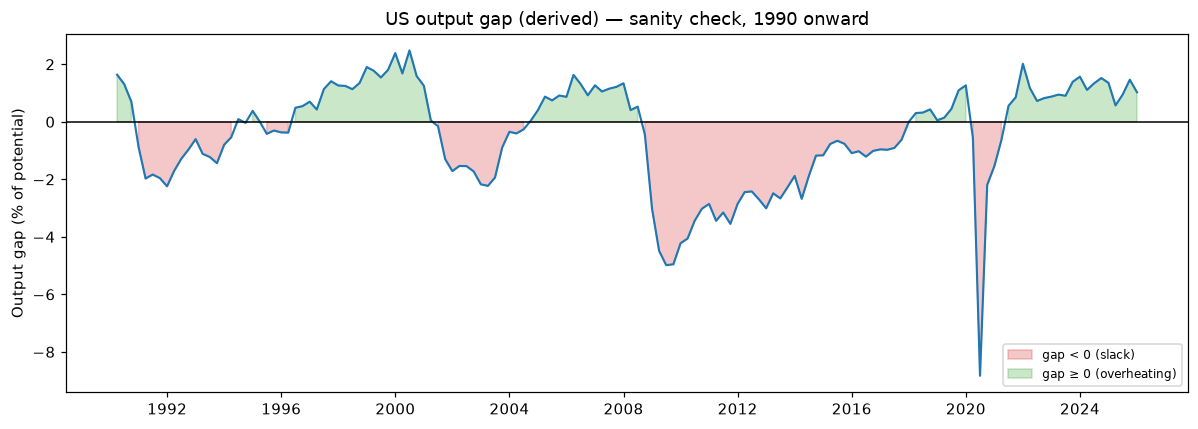

[FIG] saved -> output_gap_diagnostic.png

Output-gap values at key quarters (expected sign in brackets):
  2008-Q4 (2008-12-31):   -3.03%   expected NEGATIVE   -> PASS
  2009-Q2 (2009-06-30):   -4.99%   expected NEGATIVE   -> PASS
  2020-Q2 (2020-06-30):   -8.83%   expected NEGATIVE   -> PASS
  2021-Q4 (2021-12-31):   +2.02%   expected POSITIVE/~0   -> PASS
  2022-Q2 (2022-06-30):   +0.72%   expected POSITIVE/~0   -> PASS

[CHECK] PASS — output gap is correctly oriented (actual − potential). No inversion needed; the formula is correct.

Gap -> inflation, positive-lag scan  (gap LEADS by k quarters)
  corr(gap_t, CPI-YoY_(t+k));  n0=302, 95% band ±0.113
   lag k        r      n  sig?
      +0   -0.001    302  
      +1   +0.047    301  
      +2   +0.084    300  
      +3   +0.105    299  
      +4   +0.098    298  
      +5   +0.096    297  
      +6   +0.080    296  
      +7   +0.055    295  
      +8   +0.034    294  

  READ-OUT: a POSITIVE (textbook) correlation does appear with t

In [7]:
import matplotlib.pyplot as plt

_gap = get_series("output_gap")
if _gap is None:
    print("[WARN] output_gap not available — skipping sanity check.")
else:
    # Plot the gap from 1990 to 2025 with a zero reference line.
    _g = _gap[(_gap.index >= "1990-01-01") & (_gap.index <= "2025-12-31")].dropna()
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(_g.index, _g.values, lw=1.4, color="#1f77b4")
    ax.axhline(0, color="black", lw=1.0)
    ax.fill_between(_g.index, _g.values, 0, where=_g.values < 0,
                    color="#d62728", alpha=0.25, label="gap < 0 (slack)")
    ax.fill_between(_g.index, _g.values, 0, where=_g.values >= 0,
                    color="#2ca02c", alpha=0.25, label="gap ≥ 0 (overheating)")
    ax.set_title("US output gap (derived) — sanity check, 1990 onward")
    ax.set_ylabel("Output gap (% of potential)")
    ax.legend(loc="lower right", fontsize=8)
    fig.tight_layout()
    _diag_png = str(Path(OUTPUT_DIR) / "output_gap_diagnostic.png")
    fig.savefig(_diag_png, dpi=300)
    plt.show()
    print(f"[FIG] saved -> {_diag_png}\n")

    # Print the gap at the specific quarters the spec calls out, then PASS/FAIL.
    _checks = {
        "2008-Q4": ("2008-12-31", "neg"),
        "2009-Q2": ("2009-06-30", "neg"),
        "2020-Q2": ("2020-06-30", "neg"),
        "2021-Q4": ("2021-12-31", "pos"),
        "2022-Q2": ("2022-06-30", "pos"),
    }
    _idx_str = _gap.index.astype(str)
    print("Output-gap values at key quarters (expected sign in brackets):")
    _all_ok = True
    for _label, (_ts, _want) in _checks.items():
        _hit = _gap[_idx_str == _ts]
        if _hit.empty:
            # fall back to the nearest available quarter
            _pos = _gap.index.to_series().sub(pd.Timestamp(_ts)).abs().values.argmin()
            _val = float(_gap.iloc[_pos])
            _asof = str(_gap.index[_pos].date())
        else:
            _val = float(_hit.iloc[0]); _asof = _ts
        if _want == "neg":
            _ok = _val < 0
        else:
            _ok = _val > -0.5   # "positive or near zero"
        _all_ok = _all_ok and _ok
        print(f"  {_label} ({_asof}):  {_val:+6.2f}%   "
              f"expected {'NEGATIVE' if _want=='neg' else 'POSITIVE/~0'}   "
              f"-> {'PASS' if _ok else 'FAIL'}")
    if _all_ok:
        print("\n[CHECK] PASS — output gap is correctly oriented "
              "(actual − potential). No inversion needed; the formula is correct.")
    else:
        print("\n[CHECK] FAIL — signs look reversed. The gap formula would need to "
              "be (actual − potential)/potential, with actual real GDP on top.")

    # --- Positive-lag scan: does gap LEAD inflation at ANY horizon? ----------
    # Convention (same as cross_corr): corr(gap_t, CPI-YoY_{t+k}) for k = 0..+8
    # means "the gap LEADS inflation by k quarters". We use the gap in LEVELS and
    # CPI as YoY % (exactly the transforms relationship 3 uses) so this table is
    # directly comparable to the auto-peak. Textbook expectation: a POSITIVE r at
    # a small positive lag (gap opens -> inflation follows a few quarters later).
    _cpi = get_series("cpi")
    if _cpi is None:
        print("\n[WARN] cpi not available — skipping gap->inflation lag scan.")
    else:
        _cpi_yoy = _cpi.pct_change(PERIODS_YR) * 100.0          # YoY % (quarterly)
        _aligned = pd.concat([_gap, _cpi_yoy], axis=1).dropna()
        _aligned.columns = ["gap", "cpi_yoy"]
        _n0 = len(_aligned)
        _band = 1.96 / np.sqrt(_n0) if _n0 > 0 else np.nan
        print(f"\nGap -> inflation, positive-lag scan  (gap LEADS by k quarters)")
        print(f"  corr(gap_t, CPI-YoY_(t+k));  n0={_n0}, 95% band ±{_band:.3f}")
        print(f"  {'lag k':>6} {'r':>8} {'n':>6}  sig?")
        _best_pos = None
        for _k in range(0, 9):
            _pair = pd.concat([_aligned["gap"],
                               _aligned["cpi_yoy"].shift(-_k)], axis=1).dropna()
            _rk = (_pair.iloc[:, 0].corr(_pair.iloc[:, 1])
                   if len(_pair) > 3 else np.nan)
            _nk = len(_pair)
            _sig = (not np.isnan(_rk)) and abs(_rk) > _band
            print(f"  {('+'+str(_k)):>6} {_rk:>+8.3f} {_nk:>6}  "
                  f"{'*' if _sig else ''}")
            if not np.isnan(_rk) and _rk > 0 and (_best_pos is None or _rk > _best_pos[1]):
                _best_pos = (_k, _rk)
        if _best_pos and _best_pos[1] > 0:
            _sig_best = _best_pos[1] > _band
            print(f"\n  READ-OUT: a POSITIVE (textbook) correlation does appear with "
                  f"the gap leading — strongest at lag +{_best_pos[0]} "
                  f"(r={_best_pos[1]:+.3f}, "
                  f"{'significant' if _sig_best else 'NOT significant vs the ±%.3f band' % _band}).")
            print("  So the textbook sign is present at a short positive horizon — but "
                  "weakly. The auto-peak (largest |r| over ±12) still landed at the "
                  "negative lag -11, so over the full sample neither feature is strong.")
        else:
            print("\n  READ-OUT: no positive correlation at any lag 0..+8 — over the "
                  "full sample the gap does NOT lead inflation with the textbook sign; "
                  "the auto-peak's negative -11 is the honest dominant feature.")

## 2 · Relationships

Each section: a markdown note on the expected economics and which principles
bite hardest, then a single call to `analyze_relationship` that prints the full
report and draws the two-panel figure.

> **This run (US-primary, quarterly).** Because the workbook has no WTI crude
> *price*, the energy series and the Principle-4 common driver both use **US
> Energy Inflation** (already a `%`, so it enters in *levels*, not differenced
> again). The output gap is the **derived** US gap and the FX section pairs
> **USD/CAD** with the **US−Canada** policy-rate differential.

In [8]:
def pick(*keys):
    """Return the first logical key that is actually available (else the first)."""
    for k in keys:
        if get_series(k) is not None:
            return k
    return keys[0]

def energy_driver():
    """Pick the energy series and the transform it needs.

    WTI is a price -> compare in YoY %. Energy Inflation is already a % -> use
    in levels (differencing it again would be wrong).
    """
    if get_series("wti") is not None:
        return "wti", "yoy"
    if get_series("energy_ppi") is not None:
        return "energy_ppi", "level"
    return "wti", "yoy"   # absent -> Principle-4 control will be skipped

### 2.1 · Okun's Law — ΔUnemployment vs GDP growth  *(expect inverse)*

When the economy grows faster than trend, firms hire and unemployment falls.
**Why these principles bite:** GDP growth is already a stationary rate, but the
unemployment *rate* often tests I(1), so the honest comparison is the **change**
in unemployment vs growth (Principle 1). Okun is close to contemporaneous, so the
cross-correlation (Principle 2) mainly confirms a near-zero peak lag. It is one of
the more *stable* macro relationships, a useful contrast to the Phillips curve.

1 · Okun's Law — ΔUnemployment vs GDP growth   ·   [US]
Expected economics: inverse: faster growth -> falling unemployment

[P1] Stationarity & transform
     unemployment     ADF order=I(0)  (p_lvl=0.004) -> transform: Δ first-difference
     gdp_growth       ADF order=I(0)  (p_lvl=0.000) -> transform: levels (auto: I(0))
     Cointegration: n/a — unemployment, gdp_growth are stationary / used in levels (a stationary series cannot be cointegrated).



[P2] Lead / lag (cross-correlation)
     Headline corr (contemporaneous, on transform) = -0.729  (n=312, 95% band ±0.111)
     Auto-peak   = -0.729 at lag +0  ->  contemporaneous
     Theory-peak = -0.729 at lag +0  ->  contemporaneous  (expected sign=-, leader=any)
     Lags exceeding 95% band: [-1, 0, 1, 4]

[P3] Regime dependence
     Break dates: none detected
     regime 1948-06..2026-03: corr=-0.729 (n=312)
     SIGN FLIP across regimes: no


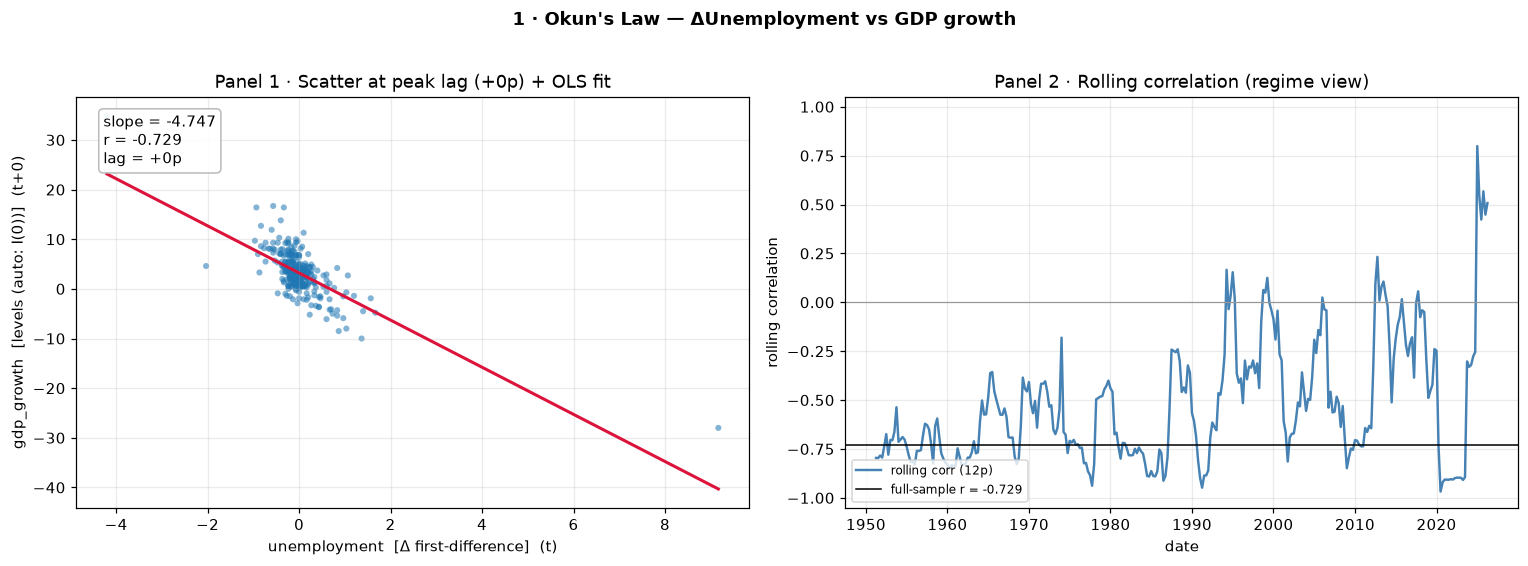


[FIG] saved -> fig_us_1_unemployment_vs_gdp_growth.png

1 · Okun's Law — ΔUnemployment vs GDP growth   ·   [Canada]
Expected economics: inverse: faster growth -> falling unemployment

[P1] Stationarity & transform
     unemployment_ca  ADF order=I(0)  (p_lvl=0.044) -> transform: Δ first-difference
     gdp_growth_ca    ADF order=I(0)  (p_lvl=0.000) -> transform: levels (auto: I(0))
     Cointegration: n/a — unemployment_ca, gdp_growth_ca are stationary / used in levels (a stationary series cannot be cointegrated).

[P2] Lead / lag (cross-correlation)
     Headline corr (contemporaneous, on transform) = -0.815  (n=240, 95% band ±0.127)
     Auto-peak   = -0.815 at lag +0  ->  contemporaneous
     Theory-peak = -0.815 at lag +0  ->  contemporaneous  (expected sign=-, leader=any)
     Lags exceeding 95% band: [0, 1]

[P3] Regime dependence
     Break dates: none detected
     regime 1966-06..2026-03: corr=-0.815 (n=240)
     SIGN FLIP across regimes: no


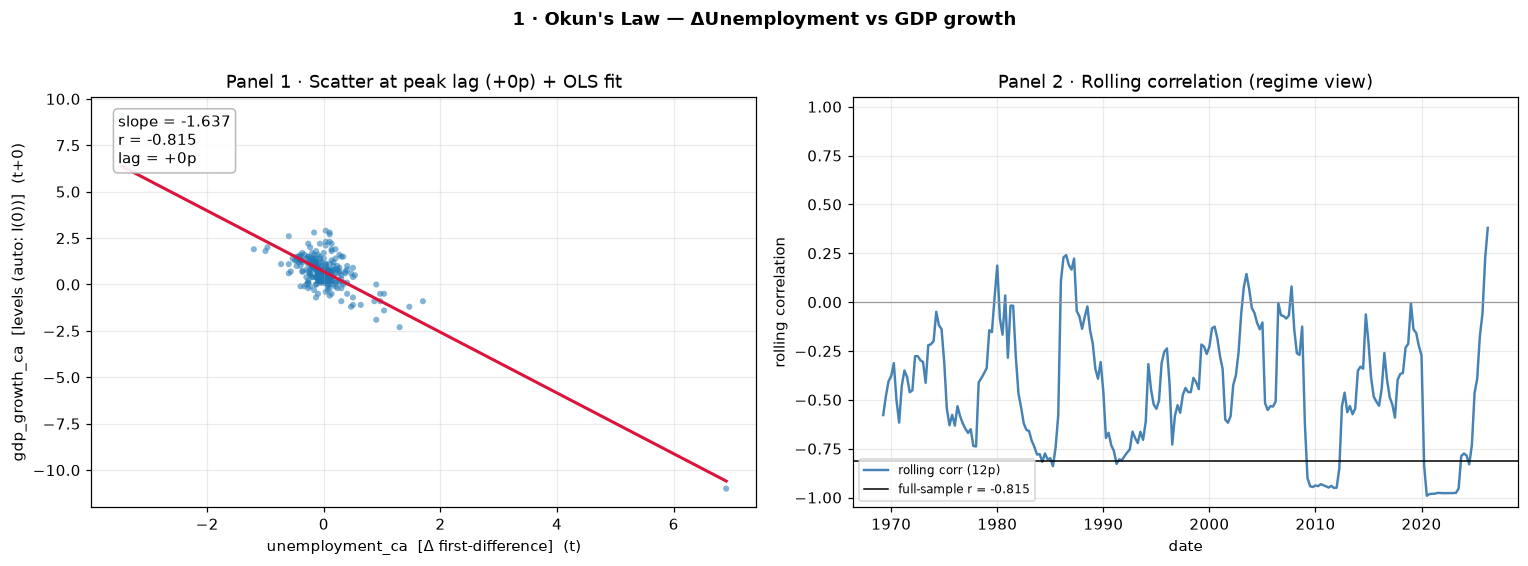


[FIG] saved -> fig_ca_1_unemployment_ca_vs_gdp_growth_ca.png



In [9]:
r = analyze_relationship(
    "rel1_okun", "1 · Okun's Law — ΔUnemployment vs GDP growth",
    "unemployment", "gdp_growth",
    x_transform="diff", y_transform="auto",
    expected_sign="-", expected_leader=None, fig_n=1, country="US",
    expect="inverse: faster growth -> falling unemployment")
if r: SUMMARY.append(r)
r = analyze_relationship(
    "rel1_okun", "1 · Okun's Law — ΔUnemployment vs GDP growth",
    "unemployment_ca", "gdp_growth_ca",
    x_transform="diff", y_transform="auto",
    expected_sign="-", expected_leader=None, fig_n=1, country="Canada",
    expect="inverse: faster growth -> falling unemployment")
if r: SUMMARY.append(r)

### 2.1a · Time-varying Okun slope — Beaton-style TVP via a Kalman smoother

A single contemporaneous correlation hides the most important fact about Okun's
law: **its slope is not constant**. This section estimates the *time-varying*
total Okun coefficient and is the sharpest expression of **Principle 3
(regime-dependence)** in the whole notebook.

**Specification (Beaton 2010, BoC SWP 2010-7).** A distributed-lag Okun
regression with random-walk coefficients,
$\;\Delta u_t = \alpha_{0,t} + \alpha_{1,t}\,\dot y_t + \alpha_{2,t}\,\dot y_{t-1}
+ \varepsilon_t,\;$ where $\Delta u_t$ is the quarterly change in the
unemployment rate (pp) and $\dot y_t$ is GDP growth. The headline is the **total
slope** $\alpha_{1,t}+\alpha_{2,t}$, traced through time.

**How it is estimated (honest, pile-up-robust).**
* The state-innovation variance $\tilde Q$ is pinned by the **Stock–Watson (1998)
  median-unbiased estimator**, inverting an **Andrews (1993) QLR** structural-break
  statistic — side-stepping the well-known MLE *pile-up at zero* that would
  otherwise force a constant slope.
* A **Lenza–Primiceri (2022)** time-varying observation variance keeps the 2020
  COVID quarters in-sample while down-weighting them, so they do not masquerade as
  a permanent regime shift.
* A **Rauch–Tung–Striebel Kalman smoother** returns the coefficient path and a
  95% pointwise band.

Note: $\dot y_t$ is the workbook's GDP **growth rate** (consistent with the §2.1
regressor), so the slope's *scale* reflects that series' units; the *time profile*
— drift, flattening, and any sign change — is the economic signal. Computed for
both the **US** and **Canada**. (Method ported from the author's separate
`cad-energy-inflation` research project.)

In [10]:
def _okun_tvp_one(country, u_key, g_key):
    """Run the TVP Okun pipeline for one country; plot + record results."""
    if _okun_tvp is None:
        print(f"   [{country}] okun_tvp unavailable — skipped.")
        return
    u = get_series(u_key); g = get_series(g_key)
    if u is None or g is None:
        print(f"   [{country}] missing {u_key!r}/{g_key!r} — skipped.")
        return
    try:
        panel = _okun_tvp.build_panel(u, g)
        if len(panel) < 24:
            print(f"   [{country}] only {len(panel)} quarters — too short, skipped.")
            return
        res = _okun_tvp.estimate_okun_tvp(panel, n_starts=5)
    except Exception as e:                     # noqa: BLE001
        print(f"   [{country}] TVP estimation failed ({e}) — skipped gracefully.")
        return

    sm_out = res["smoother"]
    idx = sm_out["time_index"]
    dates = idx.to_timestamp()
    mid = sm_out["total_okun_smoothed"]
    se  = sm_out["total_okun_smoothed_se"]
    lo, hi = mid - 1.96 * se, mid + 1.96 * se
    ols_total = res["ols_full"]["total_okun"]
    brk = res["qlrt"]["break_date"]
    brk_ts = brk.to_timestamp() if hasattr(brk, "to_timestamp") else None

    # record long rows for export
    cc = {"US": "us", "Canada": "ca"}.get(country, country.lower())
    for d, m, l, h in zip(dates, mid, lo, hi):
        OKUN_TVP.append([str(pd.Timestamp(d).date()), country, float(m), float(l), float(h)])
    reg = res["regimes"]
    for rname, row in reg.iterrows():
        OKUN_TVP_REGIMES.append([country, rname, float(row["mean"]),
                                 float(row["sem"]) if pd.notna(row["sem"]) else None,
                                 int(row["n"])])

    # report
    print(f"   [{country}] panel {len(panel)}q  {idx.min()}..{idx.max()}  |  "
          f"OLS total slope {ols_total:+.3f}  (HAC se "
          f"{res['ols_full'].get('total_okun_se', float('nan')):.3f})")
    print(f"   [{country}] Andrews QLR {res['qlrt']['qlrt_stat']:.2f} "
          f"(break {brk}) -> Stock-Watson lambda {res['lambda']:.2f}")
    print(f"   [{country}] smoothed total slope: "
          f"start {mid[0]:+.3f}  end {mid[-1]:+.3f}  "
          f"min {mid.min():+.3f}  max {mid.max():+.3f}")
    print(f"   [{country}] regime averages of smoothed slope:")
    print(reg[["mean", "sem", "n"]].round(3).to_string())
    # flag a material drift (regime-dependence / possible sign change)
    if mid.min() < 0 < mid.max():
        print(f"   [{country}] *** SLOPE CHANGES SIGN across the sample — "
              f"Okun's law is NOT stable here (Principle 3). ***")
    elif abs(mid.max() - mid.min()) > 0.10:
        print(f"   [{country}] NOTE: slope drifts materially "
              f"({mid.min():+.3f} -> {mid.max():+.3f}) — regime-dependent.")

    # figure: smoothed slope + 95% band + OLS reference + break line
    fig, ax = plt.subplots(figsize=(9, 4.2))
    ax.fill_between(dates, lo, hi, color="tab:blue", alpha=0.18,
                    label="95% pointwise CI")
    ax.plot(dates, mid, color="tab:blue", lw=2.0,
            label=r"smoothed total slope $\alpha_{1,t}+\alpha_{2,t}$")
    ax.axhline(ols_total, color="black", ls="--", lw=1.0,
               label=f"static OLS total ({ols_total:+.2f})")
    ax.axhline(0.0, color="grey", lw=0.8)
    if brk_ts is not None:
        ax.axvline(brk_ts, color="tab:red", ls=":", lw=1.2,
                   label=f"QLR break ({brk})")
    ax.set_title(f"Time-varying Okun slope — {country} "
                 f"(Beaton TVP / Kalman smoother)")
    ax.set_ylabel(r"$\alpha_{1,t}+\alpha_{2,t}$")
    ax.legend(loc="best", fontsize=8, framealpha=0.9)
    fig.tight_layout()
    fname = f"fig_{cc}_okun_tvp.png"
    fpath = str(Path(OUTPUT_DIR) / fname)
    fig.savefig(fpath, dpi=300, bbox_inches="tight")
    plt.close(fig)
    FIGURES.append(fname)
    print(f"   [{country}] saved -> {fname}\n")

print("Time-varying Okun slope (Beaton TVP / Kalman smoother):")
_okun_tvp_one("US", "unemployment", "gdp_growth")
_okun_tvp_one("Canada", "unemployment_ca", "gdp_growth_ca")

Time-varying Okun slope (Beaton TVP / Kalman smoother):


   [US] panel 312q  1948Q2..2026Q1  |  OLS total slope -0.135  (HAC se 0.034)
   [US] Andrews QLR 12.61 (break 2009Q1) -> Stock-Watson lambda 10.61
   [US] smoothed total slope: start -0.072  end -0.117  min -0.349  max +0.044
   [US] regime averages of smoothed slope:
                   mean    sem    n
regime                             
pre_1990         -0.102  0.004  120
great_moderation -0.085  0.004   75
gfc_to_covid     -0.107  0.007   40
post_covid       -0.056  0.014   25
   [US] *** SLOPE CHANGES SIGN across the sample — Okun's law is NOT stable here (Principle 3). ***
   [US] saved -> fig_us_okun_tvp.png



   [Canada] panel 240q  1966Q2..2026Q1  |  OLS total slope -0.459  (HAC se 0.084)
   [Canada] Andrews QLR 19.07 (break 1982Q4) -> Stock-Watson lambda 13.85
   [Canada] smoothed total slope: start -0.267  end -0.272  min -0.504  max -0.220
   [Canada] regime averages of smoothed slope:
                   mean    sem   n
regime                            
pre_1990         -0.349  0.009  95
great_moderation -0.367  0.007  75
gfc_to_covid     -0.338  0.004  40
post_covid       -0.353  0.016  25
   [Canada] NOTE: slope drifts materially (-0.504 -> -0.220) — regime-dependent.
   [Canada] saved -> fig_ca_okun_tvp.png



### 2.2 · Phillips Curve — Unemployment vs CPI inflation  *(expect inverse, UNSTABLE)*

Tight labour markets are supposed to push wages and prices up. **Why these
principles bite hardest here:** this is the *prime instability suspect*
(Principle 3) — the relationship flattened after the 1990s and the rolling
correlation famously flips sign. Inflation is measured as **YoY % of CPI**
(Principle 1). And because oil shocks move both inflation and the labour market,
we control for **energy** (Principle 4 — *US Energy Inflation*, since WTI price
is unavailable) to see whether any link survives.

2 · Phillips Curve — Unemployment vs CPI inflation   ·   [US]
Expected economics: inverse but unstable / regime-dependent (flattens post-1990s)

[P1] Stationarity & transform
     unemployment     ADF order=I(0)  (p_lvl=0.004) -> transform: levels (auto: I(0))
     cpi              ADF order=I(1+) (p_lvl=0.999) -> transform: YoY % (4p)
     Cointegration: n/a — unemployment, cpi are stationary / used in levels (a stationary series cannot be cointegrated).

[P2] Lead / lag (cross-correlation)
     Headline corr (contemporaneous, on transform) = +0.080  (n=302, 95% band ±0.113)
     Auto-peak   = +0.449 at lag -12  ->  cpi leads unemployment by 12p
     Theory-peak = none (no lag matches expected sign=- / leader=any)
     NOTE: lagged correlation is materially stronger than the contemporaneous one — a static matrix would miss this.
     Lags exceeding 95% band: [-12, -11, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 5, 6, 7, 8, 9, 10]

[P3] Regime dependence
     Break dates: ['1965-12', '19

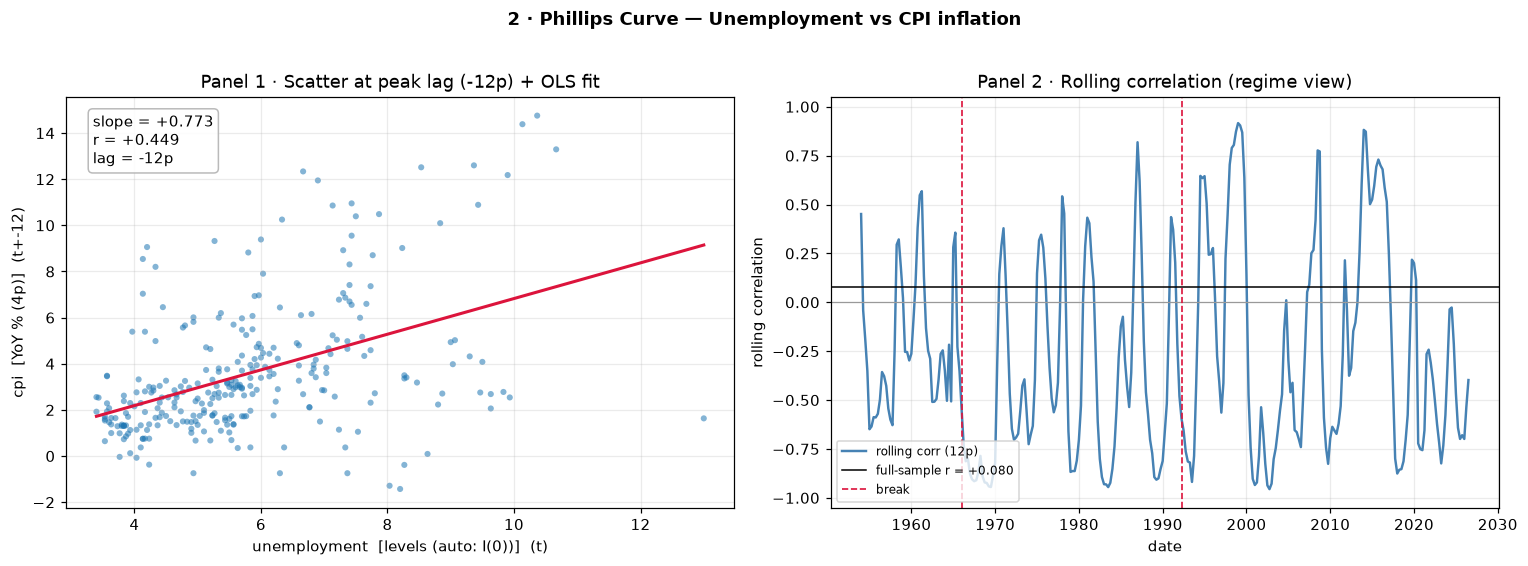


[FIG] saved -> fig_us_2_unemployment_vs_cpi.png

2 · Phillips Curve — Unemployment vs CPI inflation   ·   [Canada]
Expected economics: inverse but unstable / regime-dependent (flattens post-1990s)

[P1] Stationarity & transform
     unemployment_ca  ADF order=I(0)  (p_lvl=0.044) -> transform: levels (auto: I(0))
     cpi_ca           ADF order=I(1+) (p_lvl=0.994) -> transform: YoY % (4p)
     Cointegration: n/a — unemployment_ca, cpi_ca are stationary / used in levels (a stationary series cannot be cointegrated).

[P2] Lead / lag (cross-correlation)
     Headline corr (contemporaneous, on transform) = -0.059  (n=242, 95% band ±0.126)
     Auto-peak   = +0.435 at lag -12  ->  cpi_ca leads unemployment_ca by 12p
     Theory-peak = -0.173 at lag +12  ->  unemployment_ca  (expected sign=-, leader=any)
     DIVERGENCE: auto-peak and theory-peak differ materially (opposite sign) — the auto-peak may be noisy/spurious; theory-peak shown for honesty.
     NOTE: lagged correlation is materially

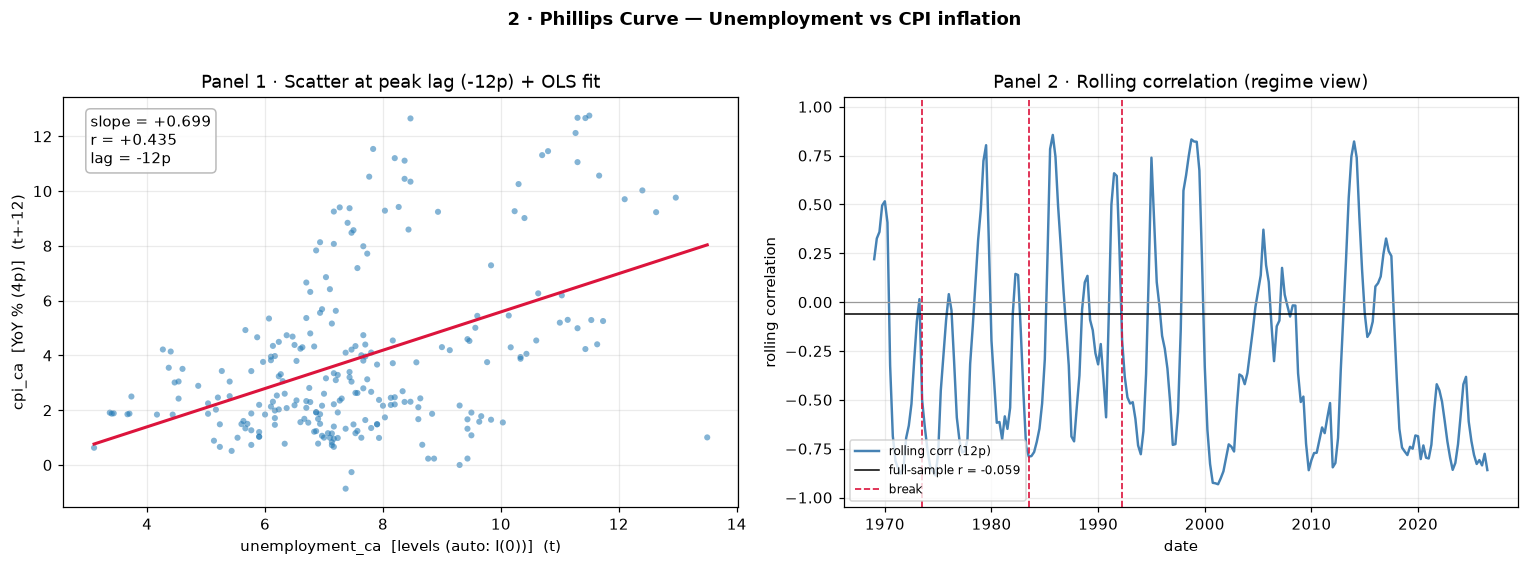


[FIG] saved -> fig_ca_2_unemployment_ca_vs_cpi_ca.png



In [11]:
_edrv, _edt = energy_driver()
r = analyze_relationship(
    "rel2_phillips", "2 · Phillips Curve — Unemployment vs CPI inflation",
    "unemployment", "cpi",
    x_transform="auto", y_transform="yoy",
    partial_driver_key=_edrv, driver_transform=_edt,
    expected_sign="-", expected_leader=None, fig_n=2, country="US",
    expect="inverse but unstable / regime-dependent (flattens post-1990s)")
if r: SUMMARY.append(r)
r = analyze_relationship(
    "rel2_phillips", "2 · Phillips Curve — Unemployment vs CPI inflation",
    "unemployment_ca", "cpi_ca",
    x_transform="auto", y_transform="yoy",
    partial_driver_key="energy_ppi_ca", driver_transform="level",
    expected_sign="-", expected_leader=None, fig_n=2, country="Canada",
    expect="inverse but unstable / regime-dependent (flattens post-1990s)")
if r: SUMMARY.append(r)

### 2.3 · Output gap vs CPI inflation  *(accelerationist: gap → Δinflation)*

A positive output gap (demand above potential) builds price pressure. **Why we
use the accelerationist form:** correlating the gap with the *level* of inflation
is dominated by the supply-shock/monetary regime (the 1970s stagflation, the
Volcker disinflation) — over the full sample the demand signal nets to ≈0 and
even flips sign. The textbook fix (Gordon's *triangle* model; Stock & Watson
1999) is the **expectations-augmented / accelerationist** Phillips curve: the gap
drives the **change in inflation** (inflation *acceleration*), not its level.
**Principles:** the gap is already stationary (use as-is, Principle 1); inflation
is entered as **Δ(YoY %)** so both sides are stationary; the action is the
**lead/lag** (Principle 2) — expect a *positive* peak with the gap leading or
coincident. A static contemporaneous correlation on the inflation *level*
understates (indeed hides) the link.

3 · Output gap vs CPI inflation   ·   [US]
Expected economics: positive; output gap LEADS the CHANGE in inflation (accelerationist PC)

[P1] Stationarity & transform
     output_gap       ADF order=I(0)  (p_lvl=0.000) -> transform: levels
     cpi              ADF order=I(1+) (p_lvl=0.999) -> transform: Δ YoY % (inflation accel., 4p)
     Cointegration: n/a — output_gap, cpi are stationary / used in levels (a stationary series cannot be cointegrated).

[P2] Lead / lag (cross-correlation)
     Headline corr (contemporaneous, on transform) = +0.218  (n=301, 95% band ±0.113)
     Auto-peak   = +0.218 at lag +0  ->  contemporaneous
     Theory-peak = +0.218 at lag +0  ->  contemporaneous  (expected sign=+, leader=x)
     Lags exceeding 95% band: [-3, -2, -1, 0, 1, 2]
     DIRECTION: peak is contemporaneous; theory expects output_gap to lead — reported as-is, not forced.

[P3] Regime dependence
     Break dates: none detected
     regime 1951-06..2026-06: corr=+0.218 (n=301)
     SIGN FLIP 

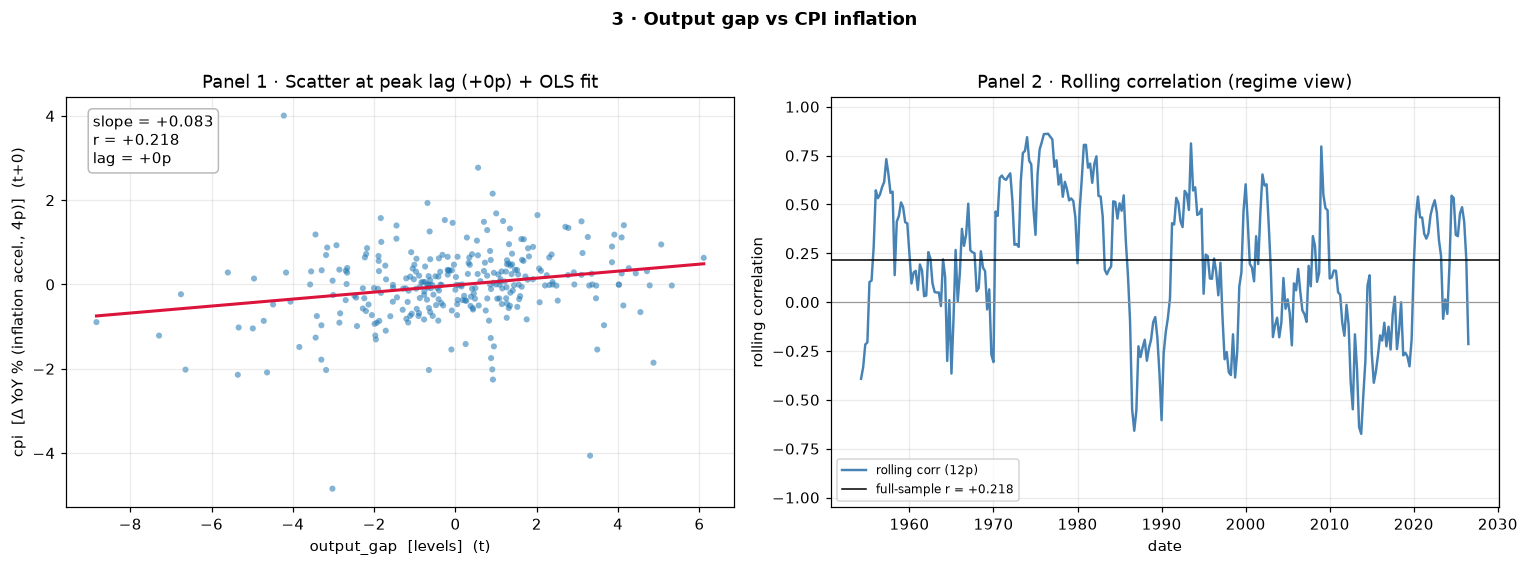


[FIG] saved -> fig_us_3_output_gap_vs_cpi.png

3 · Output gap vs CPI inflation   ·   [Canada]
Expected economics: positive; output gap LEADS the CHANGE in inflation (accelerationist PC)

[P1] Stationarity & transform
     output_gap_ca    ADF order=I(0)  (p_lvl=0.000) -> transform: levels
     cpi_ca           ADF order=I(1+) (p_lvl=0.994) -> transform: Δ YoY % (inflation accel., 4p)
     Cointegration: n/a — output_gap_ca, cpi_ca are stationary / used in levels (a stationary series cannot be cointegrated).

[P2] Lead / lag (cross-correlation)
     Headline corr (contemporaneous, on transform) = +0.218  (n=180, 95% band ±0.146)
     Auto-peak   = +0.283 at lag -1  ->  cpi_ca leads output_gap_ca by 1p
     Theory-peak = +0.218 at lag +0  ->  contemporaneous  (expected sign=+, leader=x)
     NOTE: lagged correlation is materially stronger than the contemporaneous one — a static matrix would miss this.
     Lags exceeding 95% band: [-4, -3, -2, -1, 0]
     DIRECTION WARNING: theory expec

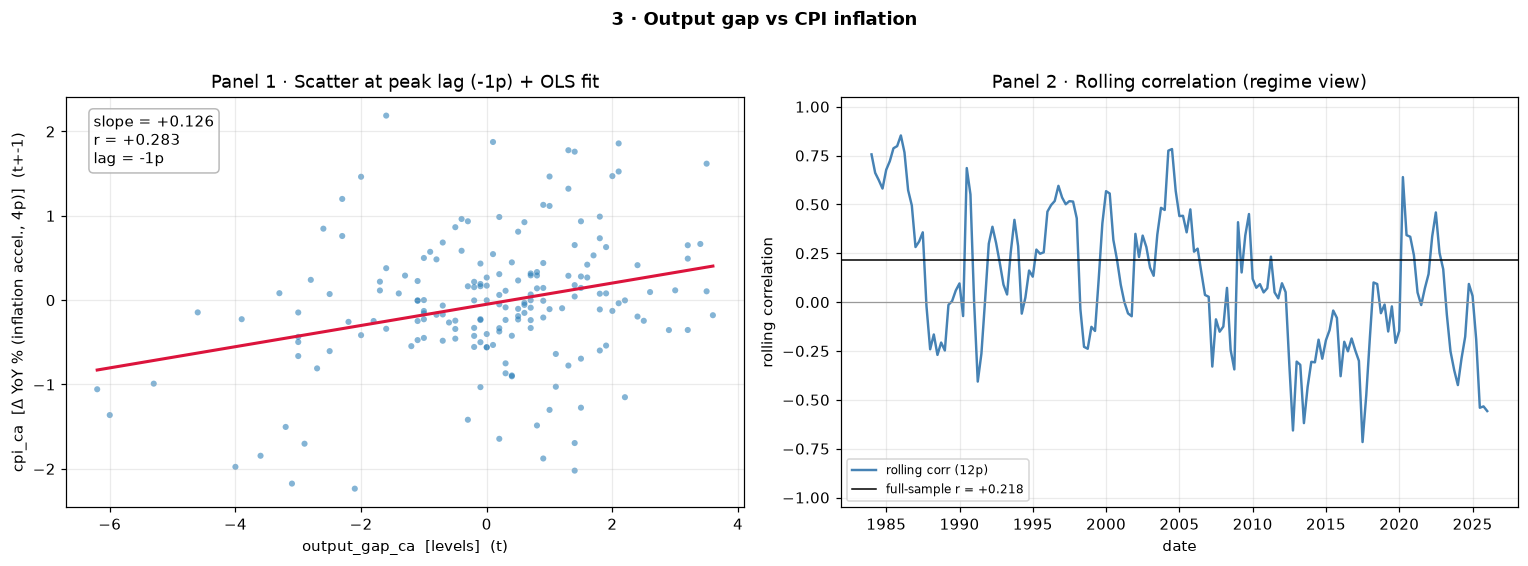


[FIG] saved -> fig_ca_3_output_gap_ca_vs_cpi_ca.png



In [12]:
r = analyze_relationship(
    "rel3_gap_infl", "3 · Output gap vs CPI inflation",
    "output_gap", "cpi",
    x_transform="level", y_transform="yoy_diff",
    expected_lead="x", expected_sign="+", expected_leader="x", fig_n=3, country="US",
    expect="positive; output gap LEADS the CHANGE in inflation (accelerationist PC)")
if r: SUMMARY.append(r)
r = analyze_relationship(
    "rel3_gap_infl", "3 · Output gap vs CPI inflation",
    "output_gap_ca", "cpi_ca",
    x_transform="level", y_transform="yoy_diff",
    expected_lead="x", expected_sign="+", expected_leader="x", fig_n=3, country="Canada",
    expect="positive; output gap LEADS the CHANGE in inflation (accelerationist PC)")
if r: SUMMARY.append(r)

### 2.4 · CPI inflation vs short-term policy rate  *(Taylor-rule positive)*

A Taylor-rule central bank raises the policy rate when inflation rises, so the
two co-move positively — but **policy reacts with a lag**, so inflation should
*lead* the rate (Principle 2). Both can be driven by the same oil shock, so we
screen with a partial correlation controlling **energy** (Principle 4 — *US
Energy Inflation*, the WTI stand-in). Levels of rates and inflation can trend
together, so we lean on the stationary transform and cointegration check
(Principle 1).

4 · CPI inflation vs short-term policy rate   ·   [US]
Expected economics: positive (Taylor rule); inflation LEADS the policy rate

[P1] Stationarity & transform
     cpi              ADF order=I(1+) (p_lvl=0.999) -> transform: YoY % (4p)
     policy_rate      ADF order=I(0)  (p_lvl=0.019) -> transform: levels (auto: I(0))
     Cointegration: n/a — cpi, policy_rate are stationary / used in levels (a stationary series cannot be cointegrated).

[P2] Lead / lag (cross-correlation)
     Headline corr (contemporaneous, on transform) = +0.291  (n=104, 95% band ±0.192)
     Auto-peak   = +0.620 at lag +6  ->  cpi leads policy_rate by 6p
     Theory-peak = +0.620 at lag +6  ->  cpi  (expected sign=+, leader=x)
     NOTE: lagged correlation is materially stronger than the contemporaneous one — a static matrix would miss this.
     Lags exceeding 95% band: [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
     DIRECTION: matches theory — cpi leads (expected).

[P3] Regime dependence
     Break date

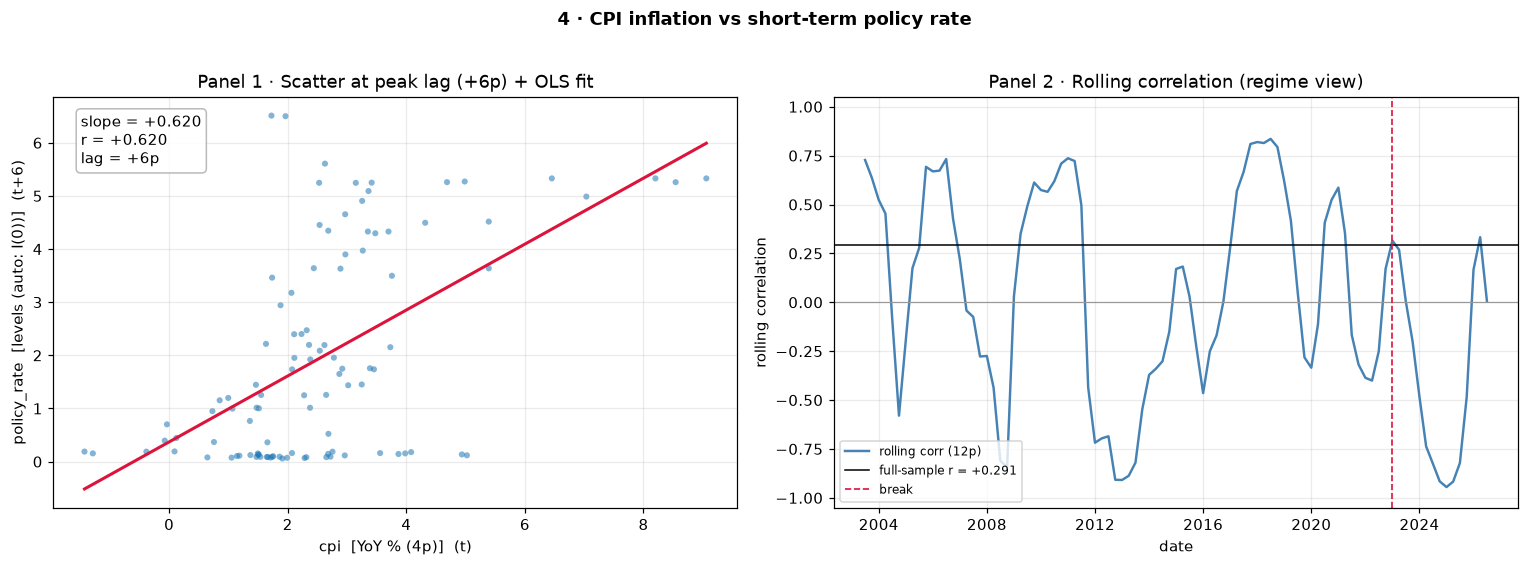


[FIG] saved -> fig_us_4_cpi_vs_policy_rate.png

4 · CPI inflation vs short-term policy rate   ·   [Canada]
Expected economics: positive (Taylor rule); inflation LEADS the policy rate

[P1] Stationarity & transform
     cpi_ca           ADF order=I(1+) (p_lvl=0.994) -> transform: YoY % (4p)
     policy_rate_ca   ADF order=I(1)  (p_lvl=0.236) -> transform: levels
     Cointegration: n/a — cpi_ca, policy_rate_ca are stationary / used in levels (a stationary series cannot be cointegrated).

[P2] Lead / lag (cross-correlation)
     Headline corr (contemporaneous, on transform) = +0.356  (n=146, 95% band ±0.162)
     Auto-peak   = +0.383 at lag +2  ->  cpi_ca leads policy_rate_ca by 2p
     Theory-peak = +0.383 at lag +2  ->  cpi_ca  (expected sign=+, leader=x)
     Lags exceeding 95% band: [-12, -11, -10, -9, -8, -7, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
     DIRECTION: matches theory — cpi_ca leads (expected).

[P3] Regime dependence
     Break dates: ['2001-03']
     regime 1

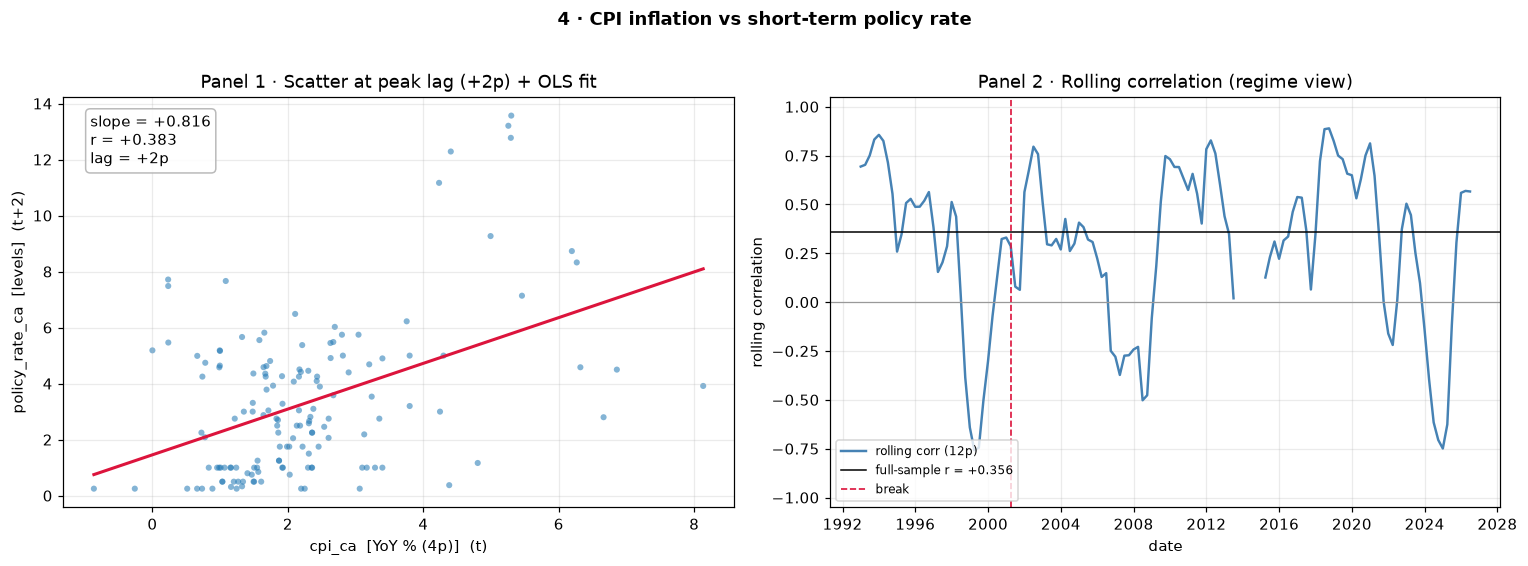


[FIG] saved -> fig_ca_4_cpi_ca_vs_policy_rate_ca.png



In [13]:
_edrv, _edt = energy_driver()
r = analyze_relationship(
    "rel4_infl_rate", "4 · CPI inflation vs short-term policy rate",
    "cpi", "policy_rate",
    x_transform="yoy", y_transform="auto",
    partial_driver_key=_edrv, driver_transform=_edt,
    expected_lead="x", expected_sign="+", expected_leader="x", fig_n=4, country="US",
    expect="positive (Taylor rule); inflation LEADS the policy rate")
if r: SUMMARY.append(r)
r = analyze_relationship(
    "rel4_infl_rate", "4 · CPI inflation vs short-term policy rate",
    "cpi_ca", "policy_rate_ca",
    # Policy rate forced to levels — ADF I(1) result reflects ZLB era structural
    # feature, not true non-stationarity. Taylor rule is a levels relationship.
    x_transform="yoy", y_transform="level",
    partial_driver_key="energy_ppi_ca", driver_transform="level",
    expected_lead="x", expected_sign="+", expected_leader="x", fig_n=4, country="Canada",
    expect="positive (Taylor rule); inflation LEADS the policy rate")
if r: SUMMARY.append(r)

### 2.5 · Yield-curve slope (10Y–2Y) vs GDP growth  *(slope LEADS growth)*

The term spread is the classic recession predictor: a flat/inverted curve today
foreshadows weak growth in 6–18 months. **Why these principles bite:** the spread
is already stationary (use as-is, Principle 1); everything is in the **lead/lag**
(Principle 2) — we expect the peak correlation at a *positive* lag with the slope
leading growth. The rolling correlation (Principle 3) shows how reliable the
signal has been across cycles. **Apples-to-apples:** both countries now use the
**10Y–2Y** slope so the panels are directly comparable. The US slope comes from
FRED (`T10Y2Y`, back to **1976**); Canada is built from the workbook's GoC 10Y −
GoC 2Y yields (from **2001** — FRED has no Government-of-Canada 2-year benchmark,
so the Canadian leg cannot be extended further back).

5 · Yield-curve slope (10Y-2Y) vs GDP growth   ·   [US]
Expected economics: positive; 10Y-2Y curve slope LEADS GDP growth by ~6-18 months

[P1] Stationarity & transform
     spread_10y2y     ADF order=I(0)  (p_lvl=0.001) -> transform: levels
     gdp_growth       ADF order=I(0)  (p_lvl=0.000) -> transform: levels (auto: I(0))
     Cointegration: n/a — spread_10y2y, gdp_growth are stationary / used in levels (a stationary series cannot be cointegrated).

[P2] Lead / lag (cross-correlation)
     Headline corr (contemporaneous, on transform) = -0.018  (n=200, 95% band ±0.139)
     Auto-peak   = -0.236 at lag -6  ->  gdp_growth leads spread_10y2y by 6p
     Theory-peak = +0.098 at lag +2  ->  spread_10y2y  (expected sign=+, leader=x)
     DIVERGENCE: auto-peak and theory-peak differ materially (opposite sign) — the auto-peak may be noisy/spurious; theory-peak shown for honesty.
     NOTE: lagged correlation is materially stronger than the contemporaneous one — a static matrix would miss th

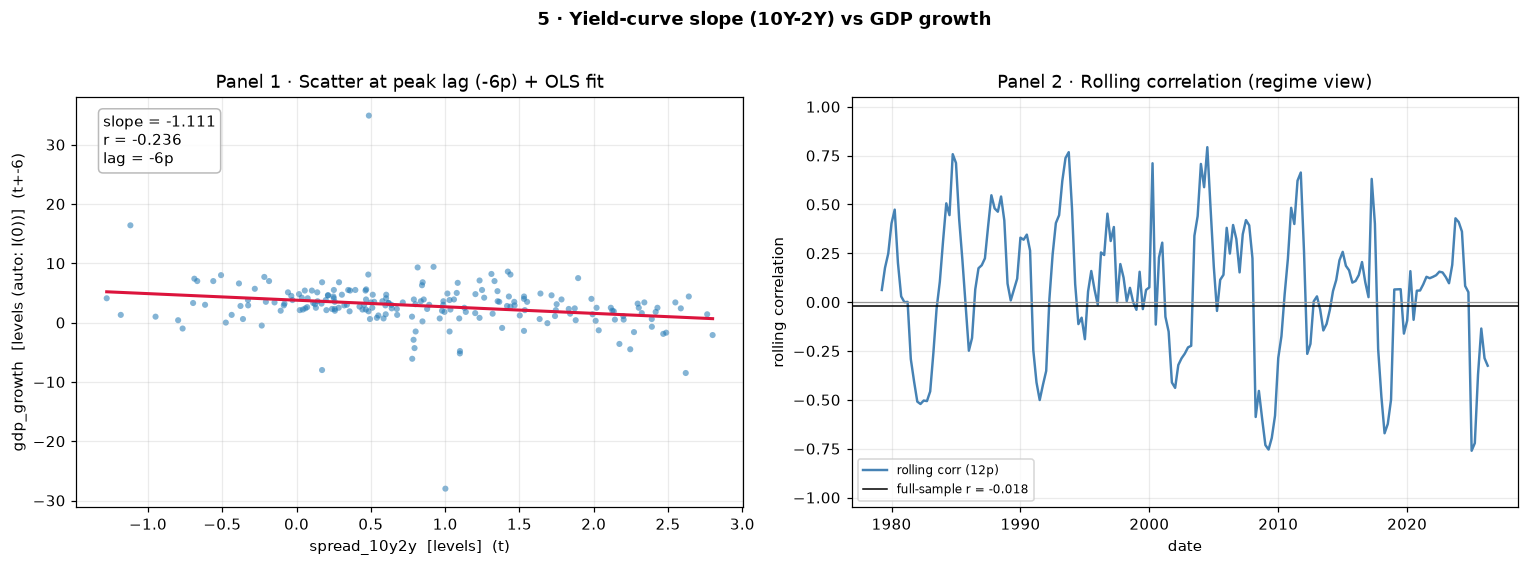


[FIG] saved -> fig_us_5_spread_10y2y_vs_gdp_growth.png

5 · Yield-curve slope (10Y-2Y) vs GDP growth   ·   [Canada]
Expected economics: positive; 10Y-2Y curve slope LEADS GDP growth (Canada GoC 10Y-2Y, 2001+)

[P1] Stationarity & transform
     spread_10y2y_ca  ADF order=I(0)  (p_lvl=0.015) -> transform: levels
     gdp_growth_ca    ADF order=I(0)  (p_lvl=0.000) -> transform: levels (auto: I(0))
     Cointegration: n/a — spread_10y2y_ca, gdp_growth_ca are stationary / used in levels (a stationary series cannot be cointegrated).

[P2] Lead / lag (cross-correlation)
     Headline corr (contemporaneous, on transform) = +0.019  (n=101, 95% band ±0.195)
     Auto-peak   = -0.169 at lag -8  ->  gdp_growth_ca leads spread_10y2y_ca by 8p
     Theory-peak = +0.088 at lag +2  ->  spread_10y2y_ca  (expected sign=+, leader=x)
     DIVERGENCE: auto-peak and theory-peak differ materially (opposite sign) — the auto-peak may be noisy/spurious; theory-peak shown for honesty.
     NOTE: lagged correlat

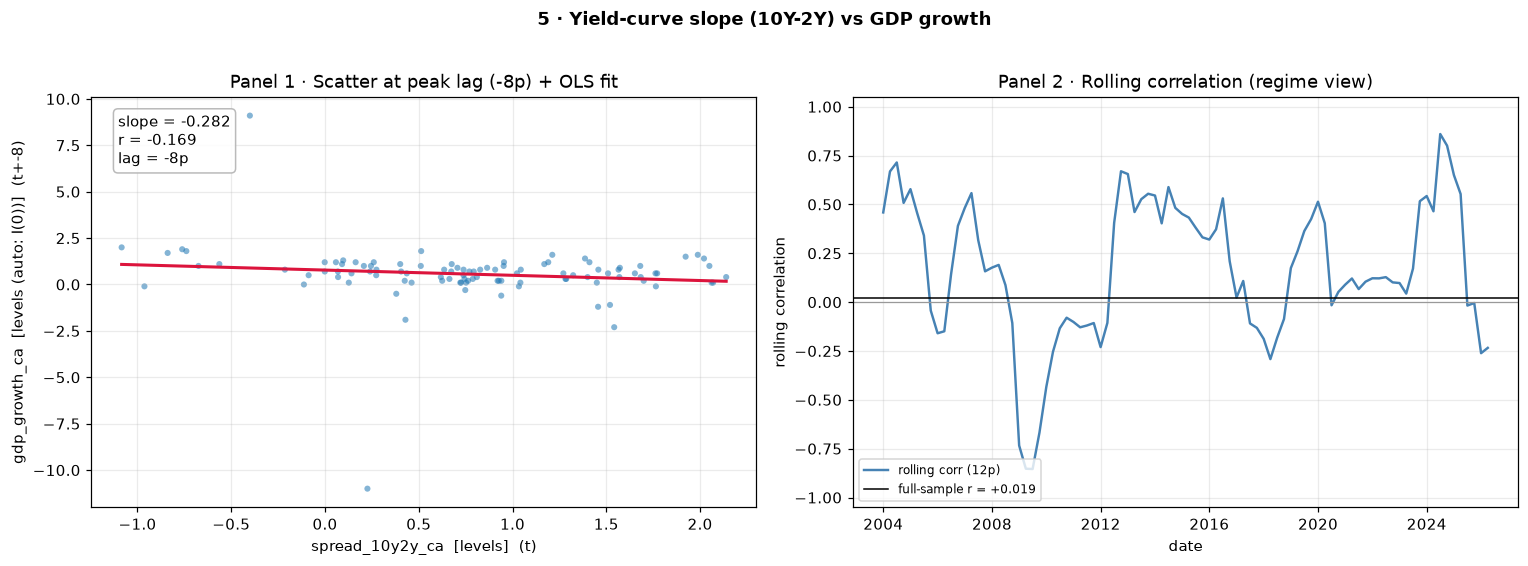


[FIG] saved -> fig_ca_5_spread_10y2y_ca_vs_gdp_growth_ca.png



In [14]:
r = analyze_relationship(
    "rel5_slope_gdp", "5 · Yield-curve slope (10Y-2Y) vs GDP growth",
    "spread_10y2y", "gdp_growth",
    x_transform="level", y_transform="auto",
    expected_lead="x", expected_sign="+", expected_leader="x", fig_n=5, country="US",
    expect="positive; 10Y-2Y curve slope LEADS GDP growth by ~6-18 months")
if r: SUMMARY.append(r)
r = analyze_relationship(
    "rel5_slope_gdp", "5 · Yield-curve slope (10Y-2Y) vs GDP growth",
    "spread_10y2y_ca", "gdp_growth_ca",
    x_transform="level", y_transform="auto",
    expected_lead="x", expected_sign="+", expected_leader="x", fig_n=5, country="Canada",
    expect="positive; 10Y-2Y curve slope LEADS GDP growth (Canada GoC 10Y-2Y, 2001+)")
if r: SUMMARY.append(r)

### 2.6 · Energy prices (WTI / energy inflation) vs CPI inflation  *(strong, fast pass-through)*

Energy feeds straight into headline prices, so the pass-through is strong, fast
and positive. **Why these principles bite:** we line up like-for-like — *US
Energy Inflation* (already a `%`) against **YoY CPI** — and expect the peak near
lag 0 or a short positive lag (Principle 2). Energy is itself *the* common driver
in Principle 4, so here we instead control for the **policy rate** to confirm the
link is supply-side pass-through and not just shared monetary conditions.

6 · Energy prices vs CPI inflation   ·   [US]
Expected economics: strong, fast, positive pass-through to headline inflation

[P1] Stationarity & transform
     energy_ppi       ADF order=I(1)  (p_lvl=0.077) -> transform: levels
     cpi              ADF order=I(1+) (p_lvl=0.999) -> transform: YoY % (4p)
     Cointegration: n/a — energy_ppi, cpi are stationary / used in levels (a stationary series cannot be cointegrated).

[P2] Lead / lag (cross-correlation)
     Headline corr (contemporaneous, on transform) = +0.796  (n=120, 95% band ±0.179)
     Auto-peak   = +0.796 at lag +0  ->  contemporaneous
     Theory-peak = +0.796 at lag +0  ->  contemporaneous  (expected sign=+, leader=x)
     Lags exceeding 95% band: [-9, -8, -7, -6, -5, -2, -1, 0, 1, 2, 3]
     DIRECTION: peak is contemporaneous; theory expects energy_ppi to lead — reported as-is, not forced.

[P3] Regime dependence
     Break dates: none detected
     regime 1996-09..2026-06: corr=+0.796 (n=120)
     SIGN FLIP across regim

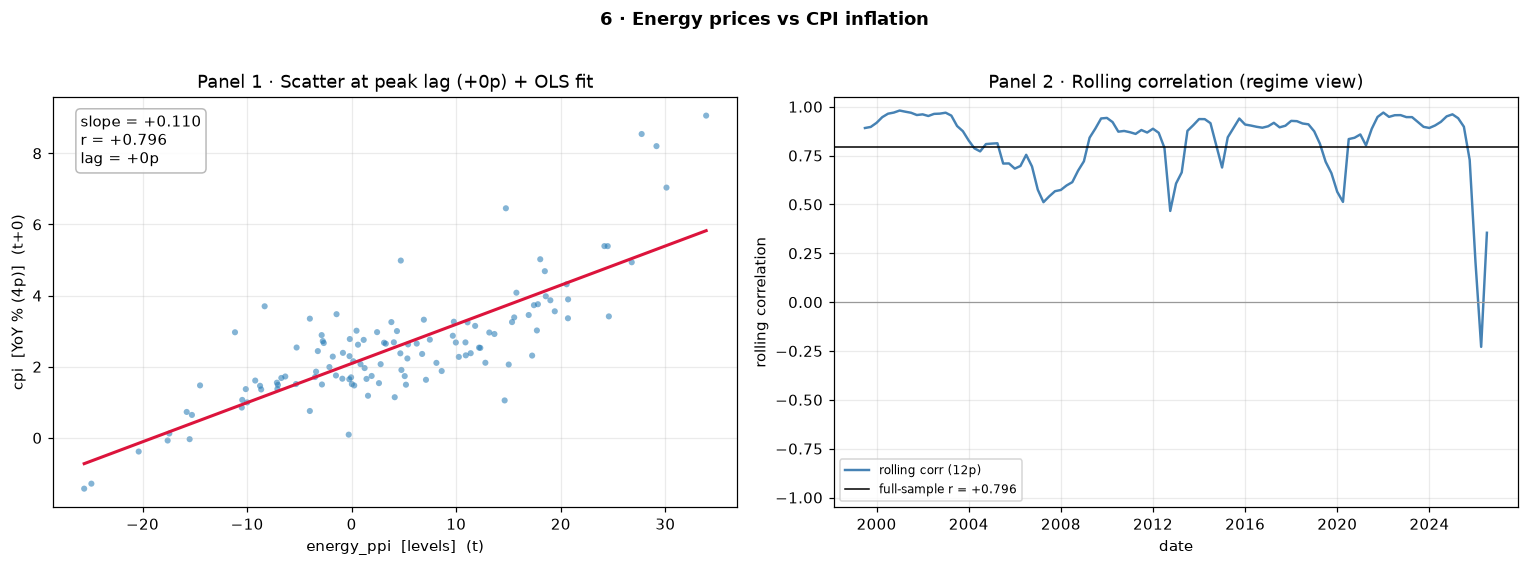


[FIG] saved -> fig_us_6_energy_ppi_vs_cpi.png

6 · Energy prices vs CPI inflation   ·   [Canada]
Expected economics: strong, fast, positive pass-through to headline inflation

[P1] Stationarity & transform
     energy_ppi_ca    ADF order=I(1)  (p_lvl=0.133) -> transform: levels
     cpi_ca           ADF order=I(1+) (p_lvl=0.994) -> transform: YoY % (4p)
     Cointegration: n/a — energy_ppi_ca, cpi_ca are stationary / used in levels (a stationary series cannot be cointegrated).

[P2] Lead / lag (cross-correlation)
     Headline corr (contemporaneous, on transform) = +0.666  (n=258, 95% band ±0.122)
     Auto-peak   = +0.666 at lag +0  ->  contemporaneous
     Theory-peak = +0.666 at lag +0  ->  contemporaneous  (expected sign=+, leader=x)
     Lags exceeding 95% band: [-12, -11, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
     DIRECTION: peak is contemporaneous; theory expects energy_ppi_ca to lead — reported as-is, not forced.

[P3] Regime depend

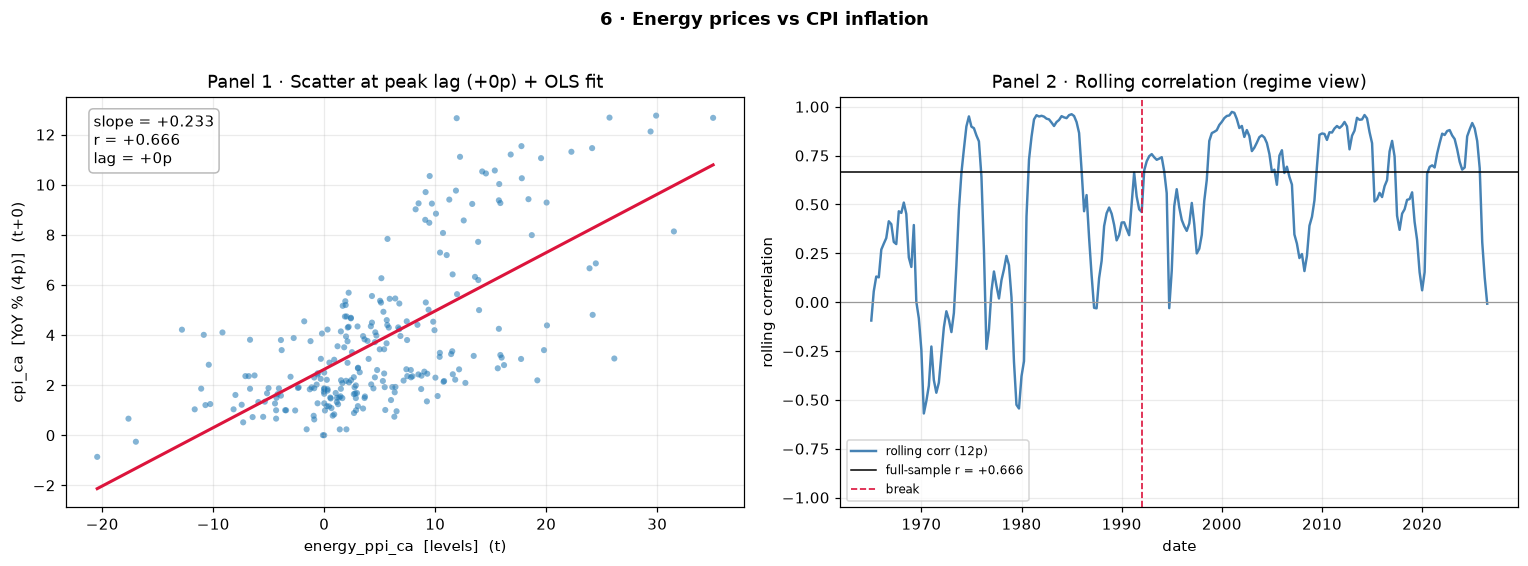


[FIG] saved -> fig_ca_6_energy_ppi_ca_vs_cpi_ca.png



In [15]:
_ekey, _edt = energy_driver()      # "wti"(yoy) if present else "energy_ppi"(level)
r = analyze_relationship(
    "rel6_energy_infl", "6 · Energy prices vs CPI inflation",
    _ekey, "cpi",
    x_transform=_edt, y_transform="yoy",
    partial_driver_key="policy_rate", driver_transform="auto",
    expected_sign="+", expected_leader="x", fig_n=6, country="US",
    expect="strong, fast, positive pass-through to headline inflation")
if r: SUMMARY.append(r)
r = analyze_relationship(
    "rel6_energy_infl", "6 · Energy prices vs CPI inflation",
    "energy_ppi_ca", "cpi_ca",
    x_transform="level", y_transform="yoy",
    partial_driver_key="policy_rate_ca", driver_transform="auto",
    expected_sign="+", expected_leader="x", fig_n=6, country="Canada",
    expect="strong, fast, positive pass-through to headline inflation")
if r: SUMMARY.append(r)

### 2.7 · Interest-rate differential vs exchange rate  *(GRAPH is the deliverable)*

Uncovered interest parity intuition: when domestic rates rise relative to
abroad, capital flows in and the currency appreciates. Here the differential is
**US − Canada** (Eff. Fed Funds − BoC overnight) and the exchange rate is
**USD/CAD**. **The graph is the deliverable** — a dual-axis time series plus the
cross-correlation; the coefficient is secondary. This is the **second prime
instability suspect** (Principle 3): the rate↔FX link is notoriously
regime-dependent (risk-on/off, carry unwinds), so expect the sign and strength
to wander.

7 · Interest-rate differential vs exchange rate   ·   [Cross-border]
Expected economics: higher relative rates -> appreciation (but regime-dependent / unstable)

[P1] Stationarity & transform
     ir_differential  ADF order=I(1+) (p_lvl=0.478) -> transform: Δ first-diff (auto: non-stationary→differenced)
     exchange_rate    ADF order=I(1)  (p_lvl=0.413) -> transform: Δ first-diff (auto: non-stationary→differenced)
     Cointegration: both series I(1)-in-levels & eligible -> Johansen runs on raw levels.
     LEVELS corr=+0.648 (*** SPURIOUS unless cointegrated ***)
     Johansen trace=6.26 vs crit95=15.49 -> cointegrated: No

[P2] Lead / lag (cross-correlation)
     Headline corr (contemporaneous, on transform) = +0.181  (n=37, 95% band ±0.322)
     Auto-peak   = +0.349 at lag -1  ->  exchange_rate leads ir_differential by 1p
     Theory-peak = +0.238 at lag +5  ->  ir_differential  (expected sign=+, leader=x)
     DIVERGENCE: auto-peak and theory-peak differ materially (|lag| gap 6) 

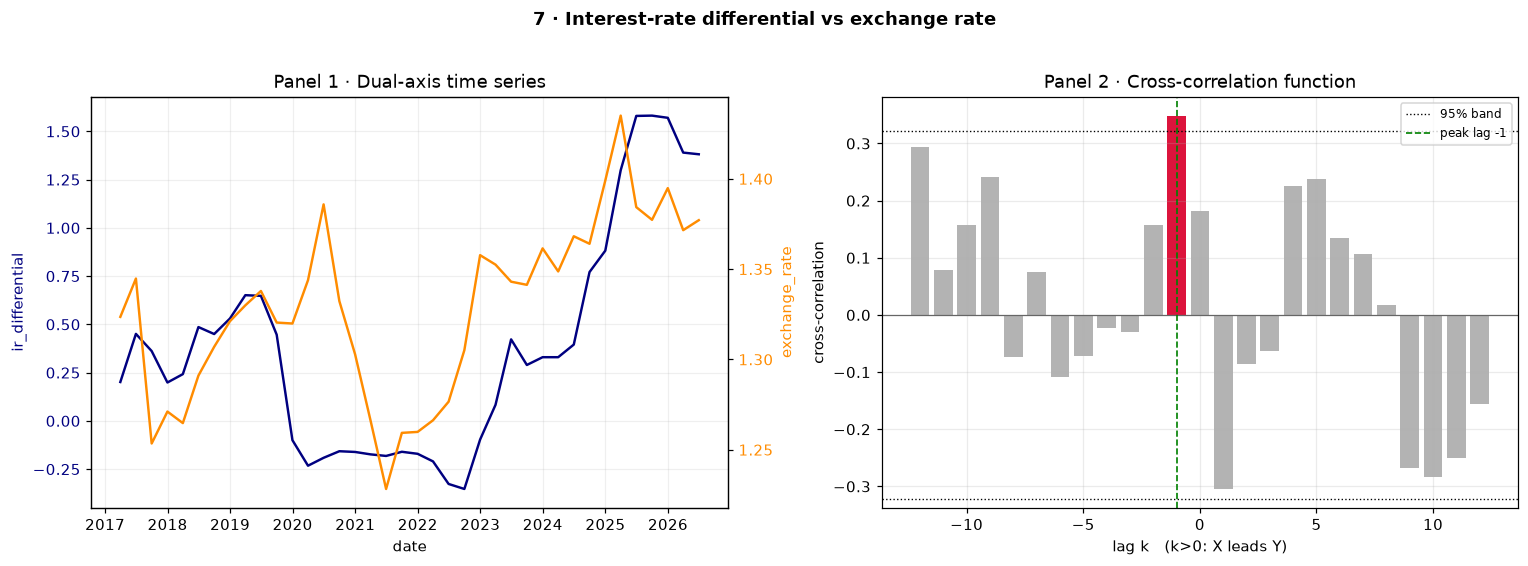


[FIG] saved -> fig_xb_7_ir_differential_vs_exchange_rate.png



In [16]:
r = analyze_relationship(
    "rel7_ir_fx", "7 · Interest-rate differential vs exchange rate",
    "ir_differential", "exchange_rate",
    x_transform="auto", y_transform="auto",
    graph_only=True,
    expected_sign="+", expected_leader="x", fig_n=7, country="Cross-border",
    expect="higher relative rates -> appreciation (but regime-dependent / unstable)")
if r: SUMMARY.append(r)

### 2.8 · VIX (market uncertainty) vs GDP growth  *(uncertainty shocks)*

The **VIX** — equity-market implied volatility — is the canonical real-time
gauge of financial-market **uncertainty / risk aversion**. Bloom (2009,
*Econometrica*) shows uncertainty spikes precede drops in real activity: firms
pause hiring and investment until the fog clears. The expected sign is
**negative** and the **VIX leads** GDP growth (Principle 2). This is the **first
market-based channel** in the set — every other relationship uses slow
fundamentals. It is sharply **regime-dependent** (Principle 3): the signal is
dominated by crisis spikes (2008 GFC, 2020 COVID), so expect breaks and a
correlation that strengthens in stress and fades in calm. Both series are
stationary, so no cointegration applies. Principle 4: we control for the
**policy rate** to check the link is risk/uncertainty, not just shared monetary
conditions.

8 · VIX vs GDP growth   ·   [US]
Expected economics: negative; market uncertainty (VIX) leads weaker GDP growth (regime-dependent)

[P1] Stationarity & transform
     vix              ADF order=I(0)  (p_lvl=0.001) -> transform: levels (auto: I(0))
     gdp_growth       ADF order=I(0)  (p_lvl=0.000) -> transform: levels (auto: I(0))
     Cointegration: n/a — vix, gdp_growth are stationary / used in levels (a stationary series cannot be cointegrated).

[P2] Lead / lag (cross-correlation)
     Headline corr (contemporaneous, on transform) = -0.319  (n=105, 95% band ±0.191)
     Auto-peak   = -0.319 at lag +0  ->  contemporaneous
     Theory-peak = -0.319 at lag +0  ->  contemporaneous  (expected sign=-, leader=x)
     Lags exceeding 95% band: [-1, 0]
     DIRECTION: peak is contemporaneous; theory expects vix to lead — reported as-is, not forced.

[P3] Regime dependence
     Break dates: none detected
     regime 2000-03..2026-03: corr=-0.319 (n=105)
     SIGN FLIP across regimes: no

[P4

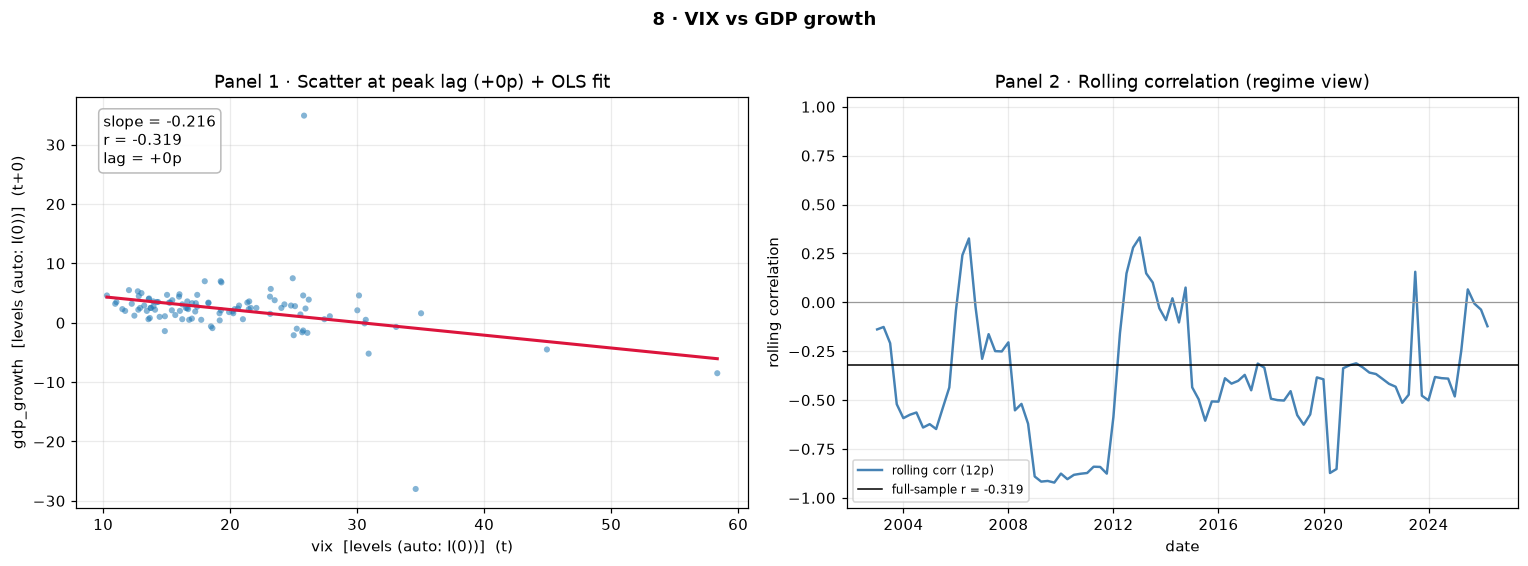


[FIG] saved -> fig_us_8_vix_vs_gdp_growth.png

8 · VIX vs GDP growth   ·   [Canada]
Expected economics: negative; global VIX uncertainty leads weaker Canadian GDP growth

[P1] Stationarity & transform
     vix              ADF order=I(0)  (p_lvl=0.001) -> transform: levels (auto: I(0))
     gdp_growth_ca    ADF order=I(0)  (p_lvl=0.000) -> transform: levels (auto: I(0))
     Cointegration: n/a — vix, gdp_growth_ca are stationary / used in levels (a stationary series cannot be cointegrated).

[P2] Lead / lag (cross-correlation)
     Headline corr (contemporaneous, on transform) = -0.245  (n=105, 95% band ±0.191)
     Auto-peak   = -0.245 at lag +0  ->  contemporaneous
     Theory-peak = -0.245 at lag +0  ->  contemporaneous  (expected sign=-, leader=x)
     Lags exceeding 95% band: [0]
     DIRECTION: peak is contemporaneous; theory expects vix to lead — reported as-is, not forced.

[P3] Regime dependence
     Break dates: none detected
     regime 2000-03..2026-03: corr=-0.245 (n=105)

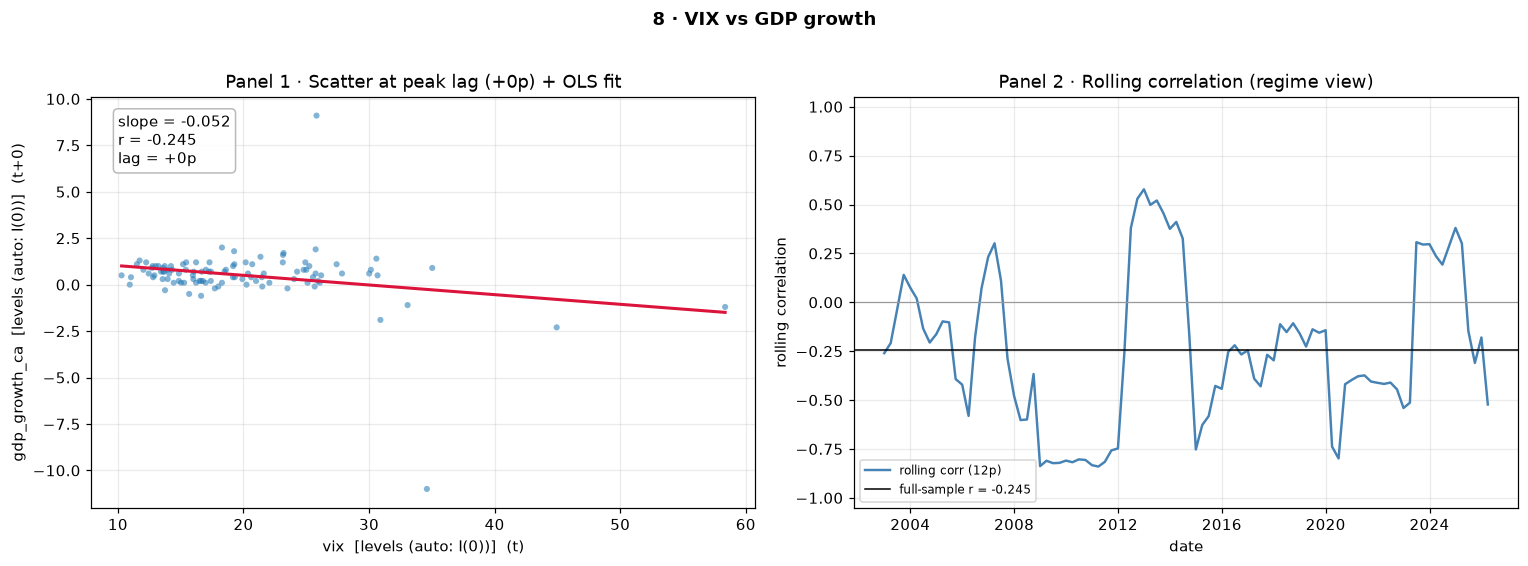


[FIG] saved -> fig_ca_8_vix_vs_gdp_growth_ca.png



In [17]:
r = analyze_relationship(
    "rel8_vix_gdp", "8 · VIX vs GDP growth",
    "vix", "gdp_growth",
    x_transform="auto", y_transform="auto",
    partial_driver_key="policy_rate", driver_transform="auto",
    expected_lead="x", expected_sign="-", expected_leader="x", fig_n=8, country="US",
    expect="negative; market uncertainty (VIX) leads weaker GDP growth (regime-dependent)")
if r: SUMMARY.append(r)
r = analyze_relationship(
    "rel8_vix_gdp", "8 · VIX vs GDP growth",
    "vix", "gdp_growth_ca",
    x_transform="auto", y_transform="auto",
    partial_driver_key="policy_rate_ca", driver_transform="auto",
    expected_lead="x", expected_sign="-", expected_leader="x", fig_n=8, country="Canada",
    expect="negative; global VIX uncertainty leads weaker Canadian GDP growth")
if r: SUMMARY.append(r)

## 3 · Dashboard exports

Four machine-readable artefacts for downstream dashboards / BI tools:

* **`relationship_summary.csv`** — *wide*, one row per relationship, every headline
  number including the honest **auto-peak vs theory-peak** split.
* **`dashboard_data.csv`** — *long / tidy*, one row per `(relationship,
  metric_name, metric_value)` so every single number is addressable.
* **`rolling_correlations.csv`** — *long*, `(date, relationship, rolling_corr)` for
  the regime-swing plots (Principle 3).
* **`ccf_data.csv`** — *long*, `(relationship, lag, r, n, sig, band)`: the full
  cross-correlation function for the interactive lead/lag dashboard.
* **`series_data.csv`** — *long*, the aligned transformed `(x, y)` pair per date —
  powers the interactive scatter-at-any-lag and time-series views.
* **`okun_tvp.csv`** — *long*, `(date, country, total_okun, lower, upper)`: the
  time-varying Okun slope with its 95% band (Beaton TVP / Kalman smoother).
* **`okun_tvp_regimes.csv`** — *long*, per-regime averages of the smoothed slope.
* **`data_asset_summary.csv`** — the coverage catalogue saved in §1.1.

In [18]:
COLUMNS = ["Relationship", "Country", "Transform", "Headline correlation",
           "Contemporaneous r", "Auto peak r", "Auto peak lag",
           "Theory peak r", "Theory peak lag", "Leading variable",
           "Cointegrated?", "Sign-flips across regimes?",
           "Survives common-driver control?", "Auto/Theory divergence"]

# (1) wide summary
if SUMMARY:
    summary_df = pd.DataFrame(SUMMARY)[COLUMNS]
    _out = str(Path(OUTPUT_DIR) / "relationship_summary.csv")
    summary_df.to_csv(_out, index=False)
    print(f"Saved -> {_out}  ({len(summary_df)} rows, wide)")
else:
    summary_df = pd.DataFrame(columns=COLUMNS)
    print("No relationships were computed (check the data warnings above).")

# (2) long / tidy dashboard data — every number as one row
dashboard_df = pd.DataFrame(DASH, columns=["relationship", "country", "metric_name", "metric_value"])
_out = str(Path(OUTPUT_DIR) / "dashboard_data.csv")
dashboard_df.to_csv(_out, index=False)
print(f"Saved -> {_out}  ({len(dashboard_df)} rows, long)")

# (3) rolling correlations (date, relationship, rolling_corr)
rolling_df = pd.DataFrame(ROLLING, columns=["date", "country", "relationship", "rolling_corr"])
_out = str(Path(OUTPUT_DIR) / "rolling_correlations.csv")
rolling_df.to_csv(_out, index=False)
print(f"Saved -> {_out}  ({len(rolling_df)} rows, long)")

# (4) cross-correlation functions (relationship, lag, r, n, sig, band)
ccf_df = pd.DataFrame(CCF, columns=["relationship", "country", "lag", "r", "n", "sig", "band"])
_out = str(Path(OUTPUT_DIR) / "ccf_data.csv")
ccf_df.to_csv(_out, index=False)
print(f"Saved -> {_out}  ({len(ccf_df)} rows, long)")

# (5) transformed paired series (relationship, date, x, y, labels) for the app
series_df = pd.DataFrame(SERIES,
    columns=["relationship", "country", "date", "x", "y", "x_label", "y_label"])
_out = str(Path(OUTPUT_DIR) / "series_data.csv")
series_df.to_csv(_out, index=False)
print(f"Saved -> {_out}  ({len(series_df)} rows, long)")

# (6) structural-break dates (relationship, break_date)
breaks_df = pd.DataFrame(BREAKS, columns=["relationship", "country", "break_date"])
_out = str(Path(OUTPUT_DIR) / "breaks_data.csv")
breaks_df.to_csv(_out, index=False)
print(f"Saved -> {_out}  ({len(breaks_df)} rows, long)")

# (7) time-varying Okun slope (date, country, total_okun, lower, upper)
okun_tvp_df = pd.DataFrame(OKUN_TVP,
    columns=["date", "country", "total_okun", "lower", "upper"])
_out = str(Path(OUTPUT_DIR) / "okun_tvp.csv")
okun_tvp_df.to_csv(_out, index=False)
print(f"Saved -> {_out}  ({len(okun_tvp_df)} rows, long)")

# (8) per-regime averages of the smoothed slope (country, regime, mean, sem, n)
okun_tvp_reg_df = pd.DataFrame(OKUN_TVP_REGIMES,
    columns=["country", "regime", "mean", "sem", "n"])
_out = str(Path(OUTPUT_DIR) / "okun_tvp_regimes.csv")
okun_tvp_reg_df.to_csv(_out, index=False)
print(f"Saved -> {_out}  ({len(okun_tvp_reg_df)} rows, long)")

print("\ndashboard_data.csv preview:")
print(dashboard_df.head(8).to_string(index=False))

Saved -> relationship_summary.csv  (15 rows, wide)
Saved -> dashboard_data.csv  (165 rows, long)
Saved -> rolling_correlations.csv  (2582 rows, long)
Saved -> ccf_data.csv  (375 rows, long)
Saved -> series_data.csv  (2753 rows, long)
Saved -> breaks_data.csv  (8 rows, long)
Saved -> okun_tvp.csv  (552 rows, long)
Saved -> okun_tvp_regimes.csv  (8 rows, long)

dashboard_data.csv preview:
                                relationship country       metric_name  metric_value
1 · Okun's Law — ΔUnemployment vs GDP growth      US             n_obs      312.0000
1 · Okun's Law — ΔUnemployment vs GDP growth      US contemporaneous_r       -0.7288
1 · Okun's Law — ΔUnemployment vs GDP growth      US       auto_peak_r       -0.7288
1 · Okun's Law — ΔUnemployment vs GDP growth      US     auto_peak_lag        0.0000
1 · Okun's Law — ΔUnemployment vs GDP growth      US     theory_peak_r       -0.7288
1 · Okun's Law — ΔUnemployment vs GDP growth      US   theory_peak_lag        0.0000
1 · Okun's Law 

## 4 · Master summary table

One row per relationship, pulling together every principle: the honest headline
(contemporaneous) correlation, the **auto-peak vs theory-peak** lead/lag figures,
whether two trending series are genuinely **cointegrated** (only where valid),
whether the sign **flips across regimes**, and whether the link **survives** the
common-driver control. The `Auto/Theory divergence` column flags any relationship
whose largest-|r| lag disagrees with the theory-consistent one.

In [19]:
summary_df

,Relationship,Country,Transform,Headline correlation,Contemporaneous r,Auto peak r,Auto peak lag,Theory peak r,Theory peak lag,Leading variable,Cointegrated?,Sign-flips across regimes?,Survives common-driver control?,Auto/Theory divergence
0,1 · Okun's Law — ΔUnemployment vs GDP growth,US,unemployment:Δ | gdp_growth:levels,-0.729,-0.729,-0.729,0,-0.729,0,—,n/a,No,n/a,—
1,1 · Okun's Law — ΔUnemployment vs GDP growth,Canada,unemployment_ca:Δ | gdp_growth_ca:levels,-0.815,-0.815,-0.815,0,-0.815,0,—,n/a,No,n/a,—
2,2 · Phillips Curve — Unemployment vs CPI infla...,US,unemployment:levels | cpi:YoY,0.080,0.080,0.449,-12,none,none,cpi,n/a,Yes,Yes,—
3,2 · Phillips Curve — Unemployment vs CPI infla...,Canada,unemployment_ca:levels | cpi_ca:YoY,-0.059,-0.059,0.435,-12,-0.173,12,cpi_ca,n/a,Yes,No (flips/collapses),auto +0.44@-12 vs theory -0.17@+12
4,3 · Output gap vs CPI inflation,US,output_gap:levels | cpi:Δ,0.218,0.218,0.218,0,0.218,0,—,n/a,No,n/a,—
5,3 · Output gap vs CPI inflation,Canada,output_gap_ca:levels | cpi_ca:Δ,0.218,0.218,0.283,-1,0.218,0,cpi_ca,n/a,No,n/a,—
6,4 · CPI inflation vs short-term policy rate,US,cpi:YoY | policy_rate:levels,0.291,0.291,0.620,6,0.62,6,cpi,n/a,Yes,Yes,—
7,4 · CPI inflation vs short-term policy rate,Canada,cpi_ca:YoY | policy_rate_ca:levels,0.356,0.356,0.383,2,0.383,2,cpi_ca,n/a,No,Yes,—
8,5 · Yield-curve slope (10Y-2Y) vs GDP growth,US,spread_10y2y:levels | gdp_growth:levels,-0.018,-0.018,-0.236,-6,0.098,2,gdp_growth,n/a,No,n/a,auto -0.24@-6 vs theory +0.10@+2
9,5 · Yield-curve slope (10Y-2Y) vs GDP growth,Canada,spread_10y2y_ca:levels | gdp_growth_ca:levels,0.019,0.019,-0.169,-8,0.088,2,gdp_growth_ca,n/a,No,n/a,auto -0.17@-8 vs theory +0.09@+2


## 4.1 · Output manifest

Every artefact produced by this run — the master notebook, the per-relationship
PNGs (`fig_<cc>_<n>_*.png` where cc = us/ca/xb, 300 dpi), the output-gap
diagnostic, and the CSVs (now carrying a **country** column for US|Canada).
(Only files this notebook generated are listed.)

In [20]:
print("Output files in", str(Path(OUTPUT_DIR).resolve()), ":\n")
print("  macro_relationships_master.ipynb   (this notebook)")
for name in FIGURES:                       # only the figures this run created
    p = Path(OUTPUT_DIR) / name
    print(f"  {name}" + ("" if p.exists() else "   (MISSING)"))
for name in ["output_gap_diagnostic.png",
             "data_asset_summary.csv", "relationship_summary.csv",
             "dashboard_data.csv", "rolling_correlations.csv",
             "ccf_data.csv", "series_data.csv", "breaks_data.csv",
             "okun_tvp.csv", "okun_tvp_regimes.csv"]:
    p = Path(OUTPUT_DIR) / name
    print(f"  {name}" + ("" if p.exists() else "   (not yet generated)"))

Output files in /Users/william.smith :

  macro_relationships_master.ipynb   (this notebook)
  fig_us_1_unemployment_vs_gdp_growth.png
  fig_ca_1_unemployment_ca_vs_gdp_growth_ca.png
  fig_us_okun_tvp.png
  fig_ca_okun_tvp.png
  fig_us_2_unemployment_vs_cpi.png
  fig_ca_2_unemployment_ca_vs_cpi_ca.png
  fig_us_3_output_gap_vs_cpi.png
  fig_ca_3_output_gap_ca_vs_cpi_ca.png
  fig_us_4_cpi_vs_policy_rate.png
  fig_ca_4_cpi_ca_vs_policy_rate_ca.png
  fig_us_5_spread_10y2y_vs_gdp_growth.png
  fig_ca_5_spread_10y2y_ca_vs_gdp_growth_ca.png
  fig_us_6_energy_ppi_vs_cpi.png
  fig_ca_6_energy_ppi_ca_vs_cpi_ca.png
  fig_xb_7_ir_differential_vs_exchange_rate.png
  fig_us_8_vix_vs_gdp_growth.png
  fig_ca_8_vix_vs_gdp_growth_ca.png
  output_gap_diagnostic.png
  data_asset_summary.csv
  relationship_summary.csv
  dashboard_data.csv
  rolling_correlations.csv
  ccf_data.csv
  series_data.csv
  breaks_data.csv
  okun_tvp.csv
  okun_tvp_regimes.csv
